## FragTime Demo


<img src="figures/FragTime_Expanded_Graphical_Abstract.png" width="750">

#### This notebook provides a complete set of tools for processing, visualizing, and investigating chemical features in ion mobility-enabled data independent (IM-DIA) workflows. The cells below are designed to be executed in the order they are written; however, in some cases, it may be necessary to iteratively fine-tune certain parameters (i.e., peak fitting thresholds, spectral deconvolution windows) depending on the data in question. 
#### FragTime is primarily a data visualization tool. Currently, an input target list of MS1 features and paths to the associated data files must be supplied prior to peak picking in the LC and IM dimensions. FragTime also includes several tools that may facilitate the reconstruction of preecursor-fragment ion relationships; these functionalities are powered by [DEIMoS](https://pubs.acs.org/doi/10.1021/acs.analchem.1c05017), the open-source Python API developed by Pacific Northwest National Laboratory. DEIMoS must be properly installed in order to properly utilize FragTime. 
#### Contact: ryan97@uw.edu (Ryan Nguyen @ Xu Lab, UW Medicinal Chemistry)

##### (1) Convert Waters .raw LC-IM-MSE (HDMSE) files to .mzML format using Watesr2mzML 

In [ ]:
# Download the Waters2mzML-1.2.0 converter at https://github.com/AnP311/Waters2mzML/releases (Written and developed by Anja Prisching)

# This converter should be run directly as a stand-alone utility 
# Navigate to the Waters2mzML-1.2.0 folder and place COPIES of the .raw files in the raw_files folder (NEVER place original files here!)
# Launch the application and type "y" to the question regarding centroiding; Waters HDMSE files always contain continuum data, by default
# Converted mzML files will appear in the mzML_files folder
# NOTE: If pre-centroided (MassLynx) LC-IM-MS files are provided, the drift time dimension will NOT be retained!
# NOTE: Running the .exe will ONLY work on LC-IM-MS files containing a LockMass (REFERENCE) function; all higher functions will be deleted otherwise
# To safely convert HDMSE files WITHOUT a REFERENCE function, refer to the instructions directly below; otherwise, proceed to the subsequent cells 

##### READ BELOW CAREFULLY to handle LC-IM-HDMSE files that DO NOT contain a LockMass (REFERENCE) function

In [ ]:
# Waters2mzML is encoded to identify and then delete the REFERENCE function; all higher functions are ignored 
# To bypass this behavior without a permanent patch, it is possible to simply paste a decoy REFERENCE function into the _extern file 
# The specified function number should be exactly one integer higher than the highest REAL function number 
# For example, in a standard HDMSE experiment containing both low and high energy scans, the _extern file will contain two functions: 
# Function 1 = low energy (no collision energy), and Function 2 = high energy (collision energy, either fixed or ramped)
# In this specific case, simply open the _extern file and paste the following text directly below Function 2:

Function Parameters - Function 3 - REFERENCE
Scan Time (sec)					1.000
Interscan Time (sec)				0.100
Start Mass					50.0
End Mass					1200.0
Start Time (mins)				0.20
End Time (mins)					1.15
Data Format					Continuum
Analyser					Resolution Mode
ADC Sample Frequency (GHz)			3.0
ADC Pusher Frequency ( s)			66.0
ADC Pusher Width ( s)				1.50
Use Tune Page Cone Voltage			YES
Using Auto Trap Collision Energy (eV)		4.000000
Using Auto Transfer Collision Energy (eV)	2.000000
Sensitivity					Normal
Dynamic Range					Normal
Save Collapsed Retention Time Data		Yes
Use Rule File Filtering				No
FragmentationMode				CID
[LOCK SPRAY]
LockSprayType:					Do not apply correction
LockSpray Reference Compound Name:		ResSP_LE
Scan Time (sec)					1.00
Interval					60
EDC Mass					0.0000
Mass Window +/-					0.5
Scans to Average				2.0
Reference Cone Voltage				30.0
Trap Collision Energy (eV)			4.0
LocksprayDRESetting				63.7200

# Note: the experimental details should be irrelevant; Waters2mzML will read the REFERENCE line and continue 

##### (2) Convert all output .txt files to .mzML files for downstream processing

In [1]:
# Recommended to activate "fragtime" environment here; otherwise, tested running Python 3.10.9

# Input libraries
from pathlib import Path
import shutil

# Define path to folder containing .txt files (the output files of Waters2mzML-1.2.0 when run in batch mode)
# Recommended to move or copy the output .txt files from Waters2mzML-1.2.0 to a new folder (e.g., "mzML Data Files") 
folder = Path("mzML Data Files") # Edit path, if necessary
txt_files = folder.glob("*.txt")

for txt in txt_files:
    mzml_path = txt.with_suffix(".mzML")
    shutil.copy(txt, mzml_path)
    print(f"Copied: {txt.name} → {mzml_path.name}")

print("Converted files to mzML.")

Converted files to mzML.


##### (3) Import DEIMoS (REQUIRED for data conversion and downstream spectral deconvolution tools)

In [37]:
# NOTE: Activate the "fragtime" environment, if not already activated

# Install DEIMoS, if not already installed 
# For detailed instructions, refer to the DEIMoS documentation here: https://deimos.readthedocs.io/en/latest/getting_started/installation.html
import deimos

print("DEIMoS version:", getattr(deimos, "__version__", "unknown"))

DEIMoS version: 1.5.1


##### (4) Load the directory of .mzML files in DEIMoS and save as .h5 (Hierarchical Data Format)

In [4]:
# Input libraries
from pathlib import Path
import traceback

# Define path to folder containing .mzML files
INPUT_DIR = Path("mzML Data Files") # Edit path, if necessary

# Converted .h5 files will be saved to this folder 
# Default name is "Hierarchical Data Files"
OUTPUT_DIR = Path("Hierarchical Data Files")

# Create the output directory folder, if not already created
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

##### (5) Run the cell below to convert the folder of .mzML files to .h5

In [ ]:
OVERWRITE = False

# Define accessions confirmed from cell above
ACCESSION_MAP = {
    "retention_time": "MS:1000016",   # Scan start time (minutes)
    "drift_time": "MS:1002476",   # Ion mobility drift time (ms or seconds; depends on writer)
}

# Convert one .mzML to .h5 with keys "ms1" and "ms2"
# Return a small dictionary of counts and the output path
def convert_one_mzml(mzml_path: Path, out_dir: Path, overwrite: bool = False) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    h5_path = out_dir / (mzml_path.stem + ".h5")
    if h5_path.exists() and not overwrite:
        return {"path": h5_path, "status": "skipped (exists)", "ms1_rows": None, "ms2_rows": None}

    # Load both MS levels 
    data = deimos.load(str(mzml_path), accession=ACCESSION_MAP)

    # Basic check
    if "ms1" not in data or "ms2" not in data:

        # Still try to save whatever exists for debugging
        if "ms1" in data:
            deimos.save(str(h5_path), data["ms1"], key="ms1", mode="w")
        if "ms2" in data:
            deimos.save(str(h5_path), data["ms2"], key="ms2", mode="a")
        have = ",".join(sorted(data.keys()))
        return {"path": h5_path, "status": f"partial (had: {have})",
                "ms1_rows": len(data.get("ms1", [])),
                "ms2_rows": len(data.get("ms2", []))}

    # Save MS1 then MS2 
    deimos.save(str(h5_path), data["ms1"], key="ms1", mode="w")
    deimos.save(str(h5_path), data["ms2"], key="ms2", mode="a")

    return {"path": h5_path, "status": "converted", "ms1_rows": len(data["ms1"]), "ms2_rows": len(data["ms2"])}

def convert_folder(mzml_dir: Path, out_dir: Path, overwrite: bool = False):
    mzml_dir = Path(mzml_dir).resolve()
    out_dir = mzml_dir.parent / out_dir # Place output folder at same level as input folder
    out_dir.mkdir(parents=True, exist_ok=True)

    # Collect *.mzML and *.mzml (non-recursive)
    files = list(mzml_dir.glob("*.mzML")) + list(mzml_dir.glob("*.mzml"))
    files = list({f.resolve(): f for f in files}.values())
    files.sort()
    if not files:
        print(f"No .mzML files found in: {mzml_dir}")
        return

    print(f"Converting {len(files)} file(s) from:\n  {mzml_dir}\n→ HDF5 to:\n  {out_dir}\n"
          f"(overwrite={'ON' if overwrite else 'OFF'})\n")

    successes = skips = failures = 0
    for i, f in enumerate(files, 1):
        try:
            info = convert_one_mzml(f, out_dir, overwrite)
            status = info["status"]
            if status.startswith("converted"):
                successes += 1
                print(f"[{i:>3}/{len(files)}] converted   → {info['path'].name}   "
                      f"(ms1={info['ms1_rows']:,}, ms2={info['ms2_rows']:,})")
            elif status.startswith("skipped"):
                skips += 1
                print(f"[{i:>3}/{len(files)}] skipped → {info['path'].name}")
            else:

                # Partial or other note
                successes += 1
                print(f"[{i:>3}/{len(files)}] partial → {info['path'].name}   status={status}")
        except Exception as e:
            failures += 1
            print(f"[{i:>3}/{len(files)}] FAILED  → {f.name}\n   {e}")
            traceback.print_exc(limit=1)

    print("\nSummary:")
    print(f"  converted: {successes}")
    print(f"  skipped:   {skips}")
    print(f"  failed:    {failures}")

# Run
convert_folder(INPUT_DIR, OUTPUT_DIR, overwrite=OVERWRITE)

Converting 3 file(s) from:
  C:\Users\ryann\Desktop\ToxCast Metabolism\mzML Data Files
→ HDF5 to:
  C:\Users\ryann\Desktop\ToxCast Metabolism\Hierarchical Data Files
(overwrite=OFF)

[  1/3] converted   → 2024_03_05_341.h5   (ms1=339,059, ms2=309,758)
[  2/3] converted   → 2024_03_25_034.h5   (ms1=529,860, ms2=493,988)
[  3/3] converted   → Plasma_203_HDMSE.h5   (ms1=834,996, ms2=698,832)

Summary:
  converted: 3
  skipped:   0
  failed:    0


##### OPTIONAL: Edit and run the two cells below to visually inspect a selected .h5 file

In [9]:
# Define path to .h5 file to be visually inspected
h5_path = Path(r"C:\Users\ryann\Desktop\ToxCast Metabolism\Hierarchical Data Files\Plasma_203_HDMSE.h5") # Edit path

In [10]:
from pathlib import Path
import pandas as pd

def inspect_h5(h5_path: Path, n=5):
    print("FILE:", h5_path)
    with pd.HDFStore(h5_path, mode="r") as store:
        keys = store.keys()
        print("\nKeys:", keys)

        for k in keys:
            df = store.select(k)  # Loads the whole file
            print(f"\n=== {k} ===")
            print("shape:", df.shape)
            print("columns:", list(df.columns))
            print("\ndtypes:")
            print(df.dtypes)
            print(f"\nhead({n}):")
            display(df.head(n))  

inspect_h5(h5_path, n=10) # Edit "n" depending on how many files to inspect

FILE: C:\Users\ryann\Desktop\ToxCast Metabolism\Hierarchical Data Files\Plasma_203_HDMSE.h5

Keys: ['/ms1', '/ms2']

=== /ms1 ===
shape: (834996, 7)
columns: ['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity']

dtypes:
function          float32
process           float32
scan              float32
retention_time    float32
drift_time        float32
mz                float32
intensity         float32
dtype: object

head(10):


,function,process,scan,retention_time,drift_time,mz,intensity
0,1.0,0.0,19.0,1.009017,0.850501,251.984451,27.0
1,1.0,0.0,21.0,1.009017,0.945001,123.062401,19.0
2,1.0,0.0,21.0,1.009017,0.945001,201.908615,13.0
3,1.0,0.0,21.0,1.009017,0.945001,276.318604,20.0
4,1.0,0.0,22.0,1.009017,0.992251,57.933357,36.0
5,1.0,0.0,22.0,1.009017,0.992251,85.938629,58.0
6,1.0,0.0,22.0,1.009017,0.992251,266.857117,24.0
7,1.0,0.0,22.0,1.009017,0.992251,285.326599,27.0
8,1.0,0.0,22.0,1.009017,0.992251,337.853882,33.0
9,1.0,0.0,23.0,1.009017,1.039501,57.938713,78.0



=== /ms2 ===
shape: (698832, 8)
columns: ['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity', 'precursor_mz']

dtypes:
function          float32
process           float32
scan              float32
retention_time    float32
drift_time        float32
mz                float32
intensity         float32
precursor_mz      float32
dtype: object

head(10):


,function,process,scan,retention_time,drift_time,mz,intensity,precursor_mz
0,2.0,0.0,203.0,1.017667,0.094500,78.149712,16.0,275.0
1,2.0,0.0,204.0,1.017667,0.141750,55.336338,12.0,275.0
2,2.0,0.0,204.0,1.017667,0.141750,92.622246,10.0,275.0
3,2.0,0.0,214.0,1.017667,0.614251,71.065453,12.0,275.0
4,2.0,0.0,215.0,1.017667,0.661501,77.346291,11.0,275.0
5,2.0,0.0,218.0,1.017667,0.803251,271.793427,21.0,275.0
6,2.0,0.0,218.0,1.017667,0.803251,291.756561,11.0,275.0
7,2.0,0.0,219.0,1.017667,0.850501,71.937057,14.0,275.0
8,2.0,0.0,219.0,1.017667,0.850501,183.859924,14.0,275.0
9,2.0,0.0,219.0,1.017667,0.850501,316.795197,20.0,275.0


##### (7) Run the cell below to load in .h5 files

In [11]:
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

def _pick_first_dataset(group: h5py.Group) -> h5py.Dataset:
    """
    Pick a likely 'main' dataset inside a group.
    Preference order: names containing 'data', 'table', 'ms1', 'ms2', else shortest path.
    """
    ds_paths = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            ds_paths.append(name)

    group.visititems(visitor)
    if not ds_paths:
        raise TypeError("Group contains no datasets.")

    # Prefer common names
    preferred = sorted(
        ds_paths,
        key=lambda p: (
            0 if any(k in p.lower() for k in ["data", "table", "ms1", "ms2"]) else 1,
            len(p)
        )
    )
    return group[preferred[0]]

def _get_columns_for_matrix(node) -> list[str] | None:
    """
    Try to recover column names for a 2D matrix table.
    """
    # If node is a dataset, check its attrs
    if isinstance(node, h5py.Dataset):
        for attr in ["columns", "colnames", "column_names"]:
            if attr in node.attrs:
                cols = node.attrs[attr]
                return [c.decode() if isinstance(c, (bytes, bytearray)) else str(c) for c in cols]

        # If dataset has a parent group, check attributes
        parent = node.parent
        if isinstance(parent, h5py.Group):
            if "columns" in parent:
                cols = parent["columns"][:]
                return [c.decode() if isinstance(c, (bytes, bytearray)) else str(c) for c in cols]
            for attr in ["columns", "colnames", "column_names"]:
                if attr in parent.attrs:
                    cols = parent.attrs[attr]
                    return [c.decode() if isinstance(c, (bytes, bytearray)) else str(c) for c in cols]

    # If node is a group, check it directly
    if isinstance(node, h5py.Group):
        if "columns" in node:
            cols = node["columns"][:]
            return [c.decode() if isinstance(c, (bytes, bytearray)) else str(c) for c in cols]
        for attr in ["columns", "colnames", "column_names"]:
            if attr in node.attrs:
                cols = node.attrs[attr]
                return [c.decode() if isinstance(c, (bytes, bytearray)) else str(c) for c in cols]

    return None

def _node_to_dataframe(node, fallback_prefix: str) -> pd.DataFrame:
    import h5py, numpy as np, pandas as pd

    if isinstance(node, h5py.Group):
        ds = _pick_first_dataset(node)
        arr = ds[:]
        cols = _get_columns_for_matrix(node) or _get_columns_for_matrix(ds)
    elif isinstance(node, h5py.Dataset):
        ds = node
        arr = ds[:]
        cols = _get_columns_for_matrix(ds)
    else:
        raise TypeError(f"Unsupported node type: {type(node)}")

    # Structured dtype 
    if hasattr(arr, "dtype") and arr.dtype.names is not None:
        data = {}
        for name in arr.dtype.names:
            v = np.asarray(arr[name])

            # Normal 1D column
            if v.ndim == 1:
                data[name] = v

            # Subarray field: expand into multiple 1D columns
            elif v.ndim == 2:
                for j in range(v.shape[1]):
                    data[f"{name}_{j}"] = v[:, j]

            else:
                raise TypeError(f"Field '{name}' has unexpected ndim={v.ndim} and shape={v.shape}")

        df = pd.DataFrame(data)

        # If we expanded a single 2D field and user provided true column names, apply them
        if cols is not None and len(cols) == df.shape[1]:
            df.columns = cols

        return df

    # Plain 2D matrix
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise TypeError(f"Expected 2D matrix or structured table, got ndim={arr.ndim}, shape={arr.shape}")

    n_rows, n_cols = arr.shape
    if cols is None or len(cols) != n_cols:
        cols = [f"{fallback_prefix}_{i}" for i in range(n_cols)]

    return pd.DataFrame(arr, columns=cols)

def load_ms_tables(h5_path: Path, verbose: bool = True):
    with h5py.File(h5_path, "r") as h5:
        if "/ms1" not in h5 or "/ms2" not in h5:
            raise KeyError(f"Expected keys '/ms1' and '/ms2' in {h5_path}")

        ms1_df = _node_to_dataframe(h5["/ms1"], fallback_prefix="ms1")
        ms2_df = _node_to_dataframe(h5["/ms2"], fallback_prefix="ms2")

    if set(["ms1_0","ms1_1","ms1_2","ms1_3","ms1_4","ms1_5","ms1_6"]).issubset(ms1_df.columns):
        ms1_df.columns = ["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity"]

    if set(["ms2_0","ms2_1","ms2_2","ms2_3","ms2_4","ms2_5","ms2_6","ms2_7"]).issubset(ms2_df.columns):
        ms2_df.columns = ["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity", "precursor_mz"]
    
    if "values_block_0_0" in ms1_df.columns:
        ms1_df = ms1_df.drop(columns=["index"], errors="ignore").copy()
        ms1_df = ms1_df.rename(columns={
            "values_block_0_0": "function",
            "values_block_0_1": "process",
            "values_block_0_2": "scan",
            "values_block_0_3": "retention_time",
            "values_block_0_4": "drift_time",
            "values_block_0_5": "mz",
            "values_block_0_6": "intensity",
    })

    if "values_block_0_0" in ms2_df.columns:
        ms2_df = ms2_df.drop(columns=["index"], errors="ignore").copy()
        ms2_df = ms2_df.rename(columns={
            "values_block_0_0": "function",
            "values_block_0_1": "process",
            "values_block_0_2": "scan",
            "values_block_0_3": "retention_time",
            "values_block_0_4": "drift_time",
            "values_block_0_5": "mz",
            "values_block_0_6": "intensity",
            "values_block_0_7": "precursor_mz",
        })
    expected_ms1 = ["function","process","scan","retention_time","drift_time","mz","intensity"]
    expected_ms2 = expected_ms1 + ["precursor_mz"]

    if all(c in ms1_df.columns for c in expected_ms1):
        ms1_df = ms1_df[expected_ms1]
    if all(c in ms2_df.columns for c in expected_ms2):
        ms2_df = ms2_df[expected_ms2]

    if verbose:
        print(f"[H5] {h5_path.name}")
        print(f"  ms1_df: {ms1_df.shape} cols={list(ms1_df.columns)}")
        print(f"  ms2_df: {ms2_df.shape} cols={list(ms2_df.columns)}")   

    return ms1_df, ms2_df

# Run for all .h5 files in OUTPUT_DIR
H5_DIR = Path(OUTPUT_DIR)
h5_files = sorted(H5_DIR.glob("*.h5"))

print(f"Found {len(h5_files)} h5 files:")

ms_data = {}

for h5_path in h5_files:
    ms1_df, ms2_df = load_ms_tables(h5_path, verbose=True)

    ms_data[h5_path.stem] = {
        "ms1": ms1_df,
        "ms2": ms2_df,
        "path": h5_path,
    }

Found 3 h5 files:
[H5] Atorvastatin.h5
  ms1_df: (529860, 7) cols=['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity']
  ms2_df: (493988, 8) cols=['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity', 'precursor_mz']
[H5] Erythromycin.h5
  ms1_df: (339059, 7) cols=['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity']
  ms2_df: (309758, 8) cols=['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity', 'precursor_mz']
[H5] Plasma_203_HDMSE.h5
  ms1_df: (834996, 7) cols=['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity']
  ms2_df: (698832, 8) cols=['function', 'process', 'scan', 'retention_time', 'drift_time', 'mz', 'intensity', 'precursor_mz']


##### (8) Edit the cell below to load in MS1 target information from Excel spreadsheet

In [12]:
# The spreadsheet should contain the following headers and information for each MS1 feature of interest 
# NOTE: All columns OTHER than Target m/z and File Name are purely for internal data tracking in the output .txt files; the values stored in these columns DO NOT influence the output
# Feature Name (REQUIRED)  --  Name of the MS1 feature that MS2 features will be assigned to; may be as simple as "Candidate_1", "Candidate_2"... etc. when the feature name is unknown
# Target m/z   (REQUIRED)  --  Target m/z value of the MS1 feature; recommended to use the m/z value(s) of interest that are observed in the raw data 
# File Name    (REQUIRED)  --  Associated HD5 (.h5) file; note that the cells above are used for converting .raw (Waters) --> .mzML (Waters2mzML) --> .h5 

# Define path to Excel spreadsheet containing MS1 target list
TARGETS_XLSX = Path("Plasma_203_fragtime.xlsx")

##### Run the cell below to load in targets

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py

from scipy.signal import find_peaks, peak_widths, savgol_filter

REQUIRED_COLS = ["Feature Name", "Target m/z", "File Name"]

def read_targets_excel(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path).copy()

    # Check required columns only
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Parse target m/z
    df["Target m/z"] = pd.to_numeric(df["Target m/z"], errors="coerce")
    if df["Target m/z"].isna().any():
        bad = df[df["Target m/z"].isna()][["Feature Name", "Target m/z", "File Name"]]
        raise ValueError(f"Some Target m/z could not be parsed:\n{bad.to_string(index=False)}")

    # Keep only relevant columns 
    df = df[REQUIRED_COLS].copy()

    return df

def resolve_h5_path(file_cell, h5_dir: Path) -> Path:
    p = Path(str(file_cell))
    if p.suffix.lower() != ".h5":
        p = p.with_suffix(".h5")
    return p if p.is_absolute() else (h5_dir / p)

# Run for user-supplied Excel spreadsheet
targets_df = read_targets_excel(TARGETS_XLSX)

print(f"Loaded {len(targets_df)} targets")
display(targets_df.head())

Loaded 1 targets


,Feature Name,Target m/z,File Name
0,Plasma_144,144.0808,Plasma_203_HDMSE.h5


##### (9) Investigate each MS1 feature to construct extracted ion chromatograms (EICs) and arrival time distributions (ATDs; also referred to as mobilograms)
##### Edit the cell below to tune parameters for LC peak picking 

In [14]:
# Tolerance in ppm around the target m/z used to filter ions in the MS1 and MS2 tables
MZ_PPM = 25.0

# Retention time bin size in min; used to build the MS1 extracted ion chromatogram (EIC)
RT_BIN_MIN = 0.01 # Smaller bins = higher resolutiion

# Minimum peak height threshold relative to the maximum signal in the trace 
MIN_REL_HEIGHT = 0.5 # Example: 0.5 = only peaks with height greater than or equal to 50% of max will be considered

# Minimum prominence threshold relative to the maximum signal in the trace
PROMINENCE_REL = 0.05 # Edit to include/exclude shouldering peaks

# Relative height for peak widths; used to define peak boundaries
LC_REL_HEIGHT = 0.5 # Example: 0.5 = approximte FWHM-like boundaries

# Savitzky-Golay smoothing parameters for ATD peak picking (must be odd; code will auto-fix if even)
SGOLAY_WINDOW = 9 # Recommended: 5–15 (smaller values preserve sharp peaks; larger values produce smoother curves)
SGOLAY_POLY = 2 # Recommended: 2-3

# Drift time bin size in ms; used to construct ATDs 
DT_BIN_MS = None # Recommended to keep None for now to mitigate artifacts due to peak picking 

# If True and MS2 table includes precursor_mz, also extract an MS2 ATD restricted to scans
# whose precursor_mz matches the target m/z 
ALSO_EXTRACT_MS2_BY_PRECURSOR = True # Recommended to keep True

# Printing and debugging
VERBOSE = True # Recommended to keep True for tracking and debugging 

##### Run the cell below to construct EICs and ATDs for all MS1 targets 

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py

from scipy.signal import find_peaks, peak_widths, savgol_filter

def ppm_window(mz: float, mz_ppm: float):
    mz = float(mz)
    ppm = float(mz_ppm) * 1e-6
    return mz * (1 - ppm), mz * (1 + ppm)


def resolve_h5_path(file_name: str, h5_dir: Path) -> Path:
    p = Path(file_name)
    if p.exists():
        return p
    return Path(h5_dir) / Path(file_name).name


def _fix_deimos_table_df(df: pd.DataFrame, expect: str) -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()

    cols = list(df.columns)

    # If already in the correct schema, return as-is
    if expect == "ms1":
        want = ["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity"]
        if all(c in cols for c in want):
            return df[want]
    if expect == "ms2":
        want = ["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity", "precursor_mz"]
        if all(c in cols for c in want):
            return df[want]

    # Handle values_block format
    vb = [c for c in cols if c.startswith("values_block_0_")]
    if len(vb) > 0:
        vb = sorted(vb, key=lambda x: int(x.split("_")[-1]))

        # Keep optional 'index' column if present then drop it
        data = df[vb].to_numpy()

        if expect == "ms1" and data.shape[1] == 7:
            out = pd.DataFrame(
                data,
                columns=["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity"],
            )
            return out

        if expect == "ms2" and data.shape[1] == 8:
            out = pd.DataFrame(
                data,
                columns=["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity", "precursor_mz"],
            )
            return out

        raise ValueError(f"Unexpected {expect} matrix width: {data.shape[1]} columns.")

    # Try to coerce from numpy dataset 
    raise ValueError(f"Could not map {expect} table columns: {cols}")


def load_ms_tables(h5_path: Path, verbose: bool = False):
    """
    Loads /ms1 and /ms2 from DEIMoS H5 into pandas DataFrames.
    Works whether they were stored as HD5Store tables or H5 datasets.
    """
    h5_path = Path(h5_path)

    # Try pandas read_hdf first 
    ms1_df = None
    ms2_df = None
    try:
        ms1_df = pd.read_hdf(h5_path, key="/ms1")
        ms2_df = pd.read_hdf(h5_path, key="/ms2")
        ms1_df = _fix_deimos_table_df(ms1_df, "ms1")
        ms2_df = _fix_deimos_table_df(ms2_df, "ms2")
        if verbose:
            print(f"[H5] {h5_path.name} (pandas)")
            print("  ms1_df:", ms1_df.shape, list(ms1_df.columns))
            print("  ms2_df:", ms2_df.shape, list(ms2_df.columns))
        return ms1_df, ms2_df
    except Exception:
        pass

    # Fallback: h5py datasets
    with h5py.File(h5_path, "r") as h5:
        if "/ms1" not in h5 or "/ms2" not in h5:
            raise KeyError(f"Expected keys '/ms1' and '/ms2' in {h5_path}")

        ms1 = h5["/ms1"][()]
        ms2 = h5["/ms2"][()]

    def _to_df(arr, expect):

        # Structured array
        if hasattr(arr, "dtype") and arr.dtype.names is not None:
            df = pd.DataFrame({k: arr[k] for k in arr.dtype.names})
            return _fix_deimos_table_df(df, expect)
        
        # Plain numeric matrix
        if isinstance(arr, np.ndarray) and arr.ndim == 2:
            if expect == "ms1" and arr.shape[1] == 7:
                return pd.DataFrame(arr, columns=["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity"])
            if expect == "ms2" and arr.shape[1] == 8:
                return pd.DataFrame(arr, columns=["function", "process", "scan", "retention_time", "drift_time", "mz", "intensity", "precursor_mz"])
            raise ValueError(f"Unexpected {expect} matrix width: {arr.shape[1]}")
        raise TypeError(f"Unsupported H5 node type for {expect}")

    ms1_df = _to_df(ms1, "ms1")
    ms2_df = _to_df(ms2, "ms2")

    if verbose:
        print(f"[H5] {h5_path.name} (h5py)")
        print("  ms1_df:", ms1_df.shape, list(ms1_df.columns))
        print("  ms2_df:", ms2_df.shape, list(ms2_df.columns))

    return ms1_df, ms2_df


def read_targets_excel(input_sheet: Path) -> pd.DataFrame:
    df = pd.read_excel(input_sheet)

    required = ["Feature Name", "Target m/z", "File Name"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required Excel columns: {missing}")

    # Normalize
    df = df.copy()
    df["Feature Name"] = df["Feature Name"].astype(str)
    df["Target m/z"] = pd.to_numeric(df["Target m/z"], errors="coerce")
    df["File Name"] = df["File Name"].astype(str)
    df = df[df["Target m/z"].notna()].reset_index(drop=True)

    return df[required]

# EIC peak building 
def build_ms1_eic(ms1_df: pd.DataFrame,
                  target_mz: float,
                  mz_ppm: float,
                  rt_bin_min: float = 0.01):
    """
    Returns (rt_centers, eic, sub_df)
    """
    lo, hi = ppm_window(target_mz, mz_ppm)
    sub = ms1_df[(ms1_df["mz"] >= lo) & (ms1_df["mz"] <= hi)].copy()
    if sub.empty:
        return np.array([]), np.array([]), sub

    rt = sub["retention_time"].to_numpy(float)
    inten = sub["intensity"].to_numpy(float)

    rt0, rt1 = float(np.min(rt)), float(np.max(rt))
    if rt1 <= rt0:

        # Handle single bin edge case
        return np.array([rt0]), np.array([float(np.sum(inten))]), sub

    nbins = int(np.ceil((rt1 - rt0) / rt_bin_min)) + 1
    edges = rt0 + np.arange(nbins + 1) * rt_bin_min
    idx = np.clip(np.digitize(rt, edges) - 1, 0, nbins - 1)

    eic = np.bincount(idx, weights=inten, minlength=nbins).astype(float)
    centers = edges[:-1] + rt_bin_min / 2.0
    return centers.astype(float), eic, sub

def find_lc_peak_windows(rt_centers, y,
                         min_rel_height=0.01,
                         prominence_rel=0.02,
                         lc_rel_height=0.5,
                         sgolay_window=9,
                         sgolay_poly=2):
    """
    Returns list of LC windows:
      (rt_left, rt_right, rt_apex, apex_height)
    """
    rt_centers = np.asarray(rt_centers, float)
    y = np.asarray(y, float)

    if len(y) == 0 or np.nanmax(y) <= 0:
        return []

    # Light smoothing for peak pick (optional)
    y_pick = y.copy()
    if sgolay_window is not None and len(y) >= max(5, int(sgolay_window)):
        w = int(sgolay_window)
        if w % 2 == 0:
            w += 1
        w = min(w, len(y) if len(y) % 2 == 1 else len(y) - 1)
        w = max(w, 5)
        if w > sgolay_poly:
            y_pick = savgol_filter(y, window_length=w, polyorder=int(sgolay_poly), mode="interp")

    ymax = float(np.nanmax(y_pick))
    peaks, _ = find_peaks(y_pick, height=ymax * float(min_rel_height), prominence=ymax * float(prominence_rel))
    if len(peaks) == 0:
        return []

    # Width-based bounds in index space
    w = peak_widths(y_pick, peaks, rel_height=float(lc_rel_height))
    left_ips, right_ips = w[2], w[3]

    out = []
    for p, li, ri in zip(peaks, left_ips, right_ips):
        li_i = max(int(np.floor(li)), 0)
        ri_i = min(int(np.ceil(ri)), len(rt_centers) - 1)
        out.append((float(rt_centers[li_i]), float(rt_centers[ri_i]), float(rt_centers[p]), float(y_pick[p])))

    # Sort by apex height desc
    out.sort(key=lambda x: x[3], reverse=True)
    return out

# ATD extraction 
def extract_atd(df: pd.DataFrame,
                mz_col: str,
                target_mz: float,
                mz_ppm: float,
                rt_left: float,
                rt_right: float,
                dt_bin_ms=None):
    """
    Returns (dt_centers, atd, sub_df)
    """
    lo, hi = ppm_window(target_mz, mz_ppm)
    sub = df[
        (df[mz_col] >= lo) & (df[mz_col] <= hi) &
        (df["retention_time"] >= float(rt_left)) & (df["retention_time"] <= float(rt_right))
    ].copy()

    if sub.empty:
        return np.array([]), np.array([]), sub

    dt = sub["drift_time"].to_numpy(float)
    inten = sub["intensity"].to_numpy(float)

    if dt_bin_ms is None:

        # Default: unique DT values (sorted)
        u = np.unique(dt)
        if len(u) == 0:
            return np.array([]), np.array([]), sub
        
        # Sum intensities per unique DT
        inv = np.searchsorted(u, dt)
        atd = np.bincount(inv, weights=inten, minlength=len(u)).astype(float)
        return u.astype(float), atd, sub

    # Binned
    dt0, dt1 = float(np.min(dt)), float(np.max(dt))
    if dt1 <= dt0:
        return np.array([dt0]), np.array([float(np.sum(inten))]), sub

    dt_bin_ms = float(dt_bin_ms)
    nbins = int(np.ceil((dt1 - dt0) / dt_bin_ms)) + 1
    edges = dt0 + np.arange(nbins + 1) * dt_bin_ms
    idx = np.clip(np.digitize(dt, edges) - 1, 0, nbins - 1)

    atd = np.bincount(idx, weights=inten, minlength=nbins).astype(float)
    centers = edges[:-1] + dt_bin_ms / 2.0
    return centers.astype(float), atd, sub

# Extract all peaks within Excel spreadsheet 
def extract_all_instances(
    input_sheet: Path,
    h5_dir: Path,
    mz_ppm: float = 10.0,
    rt_bin_min: float = 0.01,
    min_rel_height: float = 0.01,
    prominence_rel: float = 0.02,
    lc_rel_height: float = 0.5,
    sgolay_window: int = 9,
    sgolay_poly: int = 2,
    dt_bin_ms=None,
    also_extract_ms2_by_precursor: bool = True,
    verbose: bool = True,
):
    targets = read_targets_excel(input_sheet)

    cache = {}
    instances_rows = []
    atd_store = {}

    for row_index, row in targets.iterrows():
        feature_name = str(row["Feature Name"])
        target_mz = float(row["Target m/z"])
        file_name = str(row["File Name"])
        h5_path = resolve_h5_path(file_name, h5_dir)

        if verbose:
            print(f"\n[{row_index}] {feature_name} | m/z: {target_mz:.6f} | {h5_path.name}")

        if h5_path not in cache:
            cache[h5_path] = load_ms_tables(h5_path, verbose=False)

        ms1_df, ms2_df = cache[h5_path]

        # Build MS1 EIC 
        rt_centers, eic, _ = build_ms1_eic(
            ms1_df=ms1_df,
            target_mz=target_mz,
            mz_ppm=mz_ppm,
            rt_bin_min=rt_bin_min,
        )

        rt = np.asarray(rt_centers, float)
        y = np.asarray(eic, float)

        if len(y) == 0 or np.nanmax(y) <= 0:
            if verbose:
                print("   No EIC signal; skipping")
            continue

        lc_windows = find_lc_peak_windows(
            rt_centers=rt,
            y=y,
            min_rel_height=min_rel_height,
            prominence_rel=prominence_rel,
            lc_rel_height=lc_rel_height,
            sgolay_window=sgolay_window,
            sgolay_poly=sgolay_poly,
        )

        if verbose:
            print(f"    LC peaks: {len(lc_windows)}")

        for lc_peak_index, (rt_left, rt_right, rt_apex, apex_height) in enumerate(lc_windows, start=1):

            # MS1 ATD
            ms1_dt, ms1_atd, _ = extract_atd(
                df=ms1_df,
                mz_col="mz",
                target_mz=target_mz,
                mz_ppm=mz_ppm,
                rt_left=rt_left,
                rt_right=rt_right,
                dt_bin_ms=dt_bin_ms,
            )

            # MS2 ATD (same m/z)
            ms2_dt, ms2_atd, ms2_sub = extract_atd(
                df=ms2_df,
                mz_col="mz",
                target_mz=target_mz,
                mz_ppm=mz_ppm,
                rt_left=rt_left,
                rt_right=rt_right,
                dt_bin_ms=dt_bin_ms,
            )

            store_key = (row_index, lc_peak_index)
            atd_store[store_key] = {
                "ms1_dt": ms1_dt,
                "ms1_atd": ms1_atd,
                "ms2_same_mz_dt": ms2_dt,
                "ms2_same_mz_atd": ms2_atd,
            }

            # Optional: MS2 ATD filtered by precursor_mz ~ target_mz (still same fragment m/z)
            if also_extract_ms2_by_precursor and ("precursor_mz" in ms2_df.columns):
                lo_p, hi_p = ppm_window(target_mz, mz_ppm)
                ms2_prec = ms2_df[(ms2_df["precursor_mz"] >= lo_p) & (ms2_df["precursor_mz"] <= hi_p)].copy()

                ms2p_dt, ms2p_atd, _ = extract_atd(
                    df=ms2_prec,
                    mz_col="mz",
                    target_mz=target_mz,
                    mz_ppm=mz_ppm,
                    rt_left=rt_left,
                    rt_right=rt_right,
                    dt_bin_ms=dt_bin_ms,
                )
                atd_store[store_key]["ms2_by_precursor_dt"] = ms2p_dt
                atd_store[store_key]["ms2_by_precursor_atd"] = ms2p_atd

            instances_rows.append({
                "row_index": row_index,
                "lc_peak_index": lc_peak_index,
                "feature_name": feature_name,
                "target_mz": target_mz,
                "file_name": file_name,
                "h5_path": str(h5_path),
                "rt_left": rt_left,
                "rt_right": rt_right,
                "rt_apex": rt_apex,
                "rt_apex_intensity": apex_height,
                "ms1_atd_bins": int(len(ms1_dt)),
                "ms2_same_mz_atd_bins": int(len(ms2_dt)),
            })

            if verbose:
                print(f"    [LC {lc_peak_index}] RT bounds: {rt_left:.4f}-{rt_right:.4f} min "
                      f"| MS1 bins: {len(ms1_dt)} | MS2 (same m/z) bins: {len(ms2_dt)}")

    instances_df = pd.DataFrame(instances_rows)
    return instances_df, atd_store

# Run with pre-defined peak picking parameters
instances_df, atd_store = extract_all_instances(
    input_sheet=TARGETS_XLSX,
    h5_dir=H5_DIR,
    mz_ppm=MZ_PPM,
    rt_bin_min=RT_BIN_MIN,
    min_rel_height=MIN_REL_HEIGHT,
    prominence_rel=PROMINENCE_REL,
    lc_rel_height=LC_REL_HEIGHT,
    sgolay_window=SGOLAY_WINDOW,
    sgolay_poly=SGOLAY_POLY,
    dt_bin_ms=DT_BIN_MS,
    also_extract_ms2_by_precursor=ALSO_EXTRACT_MS2_BY_PRECURSOR,
    verbose=VERBOSE,
)

display(instances_df.head(20))


[0] Plasma_144 | m/z: 144.080800 | Plasma_203_HDMSE.h5
    LC peaks: 2
    [LC 1] RT bounds: 5.3469-5.4669 min | MS1 bins: 20 | MS2 (same m/z) bins: 21
    [LC 2] RT bounds: 5.4169-5.4469 min | MS1 bins: 17 | MS2 (same m/z) bins: 20


,row_index,lc_peak_index,feature_name,target_mz,file_name,h5_path,rt_left,rt_right,rt_apex,rt_apex_intensity,ms1_atd_bins,ms2_same_mz_atd_bins
0,0,1,Plasma_144,144.0808,Plasma_203_HDMSE.h5,Hierarchical Data Files\Plasma_203_HDMSE.h5,5.346933,5.466933,5.406933,14844.774892,20,21
1,0,2,Plasma_144,144.0808,Plasma_203_HDMSE.h5,Hierarchical Data Files\Plasma_203_HDMSE.h5,5.416933,5.446933,5.426933,12567.077922,17,20


##### Edit the cell below to visualize extracted ATDs for a selected MS1 feature

In [18]:
# Enter the name of the feature (EXACTLY as listed in the Excel spreadsheet) to be plotted and visualized
FEATURE_NAME = "Plasma_144"

# Set to None to plot all peaks for this feature
LC_PEAK_INDEX = None

# OPTIONAL: If multiple features share the same name, specify which to plot with the row_index (above)
ROW_INDEX = 0

##### Run the cell below to generate ATD plots

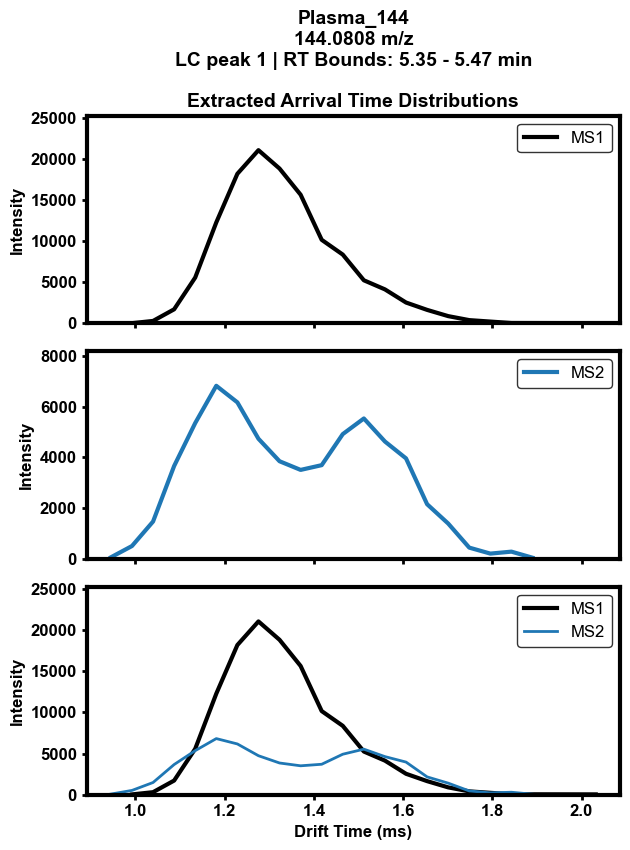

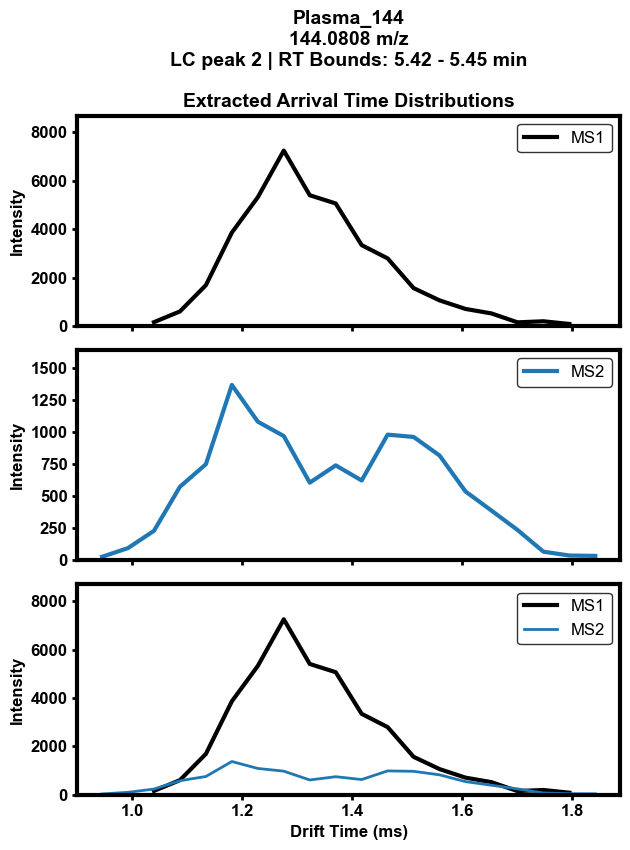

In [19]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

# Global style parameters
rcParams["font.family"] = "Arial"

def plot_ms1_ms2_atds_single_figure(
    instances_df,
    atd_store,
    feature_name,
    lc_peak_index=None,
    row_index=None,
):

    # Filter instances
    df = instances_df[instances_df["feature_name"].astype(str) == str(feature_name)].copy()
    if df.empty:
        raise ValueError(f"No instances found for feature_name: '{feature_name}'")

    if row_index is not None:
        df = df[df["row_index"] == row_index].copy()
        if df.empty:
            raise ValueError(f"No instances found for feature_name='{feature_name}' with row_index={row_index}")

    if lc_peak_index is not None:
        df = df[df["lc_peak_index"] == lc_peak_index].copy()
        if df.empty:
            raise ValueError(
                f"No instances found for feature_name='{feature_name}' with lc_peak_index={lc_peak_index} "
                f"(and row_index={row_index})."
            )

    df = df.sort_values(["row_index", "lc_peak_index"]).reset_index(drop=True)

    for _, inst in df.iterrows():
        key = (int(inst["row_index"]), int(inst["lc_peak_index"]))
        if key not in atd_store:
            print(f"Missing ATD data for key: {key}")
            continue

        data = atd_store[key]

        # Set up figure 
        fig, (ax1, ax2, ax3) = plt.subplots(
            nrows=3,
            ncols=1,
            figsize=(6.4, 8.6),
            sharex=True
        )

        # MS1 ATD
        if len(data.get("ms1_dt", [])) > 0:
            ax1.plot(
                data["ms1_dt"],
                data["ms1_atd"],
                lw=3,
                color="black",
                label="MS1",
            )
        else:
            ax1.text(0.5, 0.5, "No MS1 ATD data", ha="center", va="center", transform=ax1.transAxes)

        ax1.set_ylabel("Intensity", fontsize=12, fontweight="bold", fontname="Arial")
        ax1.set_title(
            f"{inst['feature_name']}\n"
            f"{inst['target_mz']:.4f} m/z\n"
            f"LC peak {int(inst['lc_peak_index'])} | RT Bounds: {inst['rt_left']:.2f} - {inst['rt_right']:.2f} min\n\n"
            f"Extracted Arrival Time Distributions",
            fontsize=14,
            fontweight="bold",
        )

        # MS2 ATD
        if len(data.get("ms2_same_mz_dt", [])) > 0:
            ax2.plot(
                data["ms2_same_mz_dt"],
                data["ms2_same_mz_atd"],
                lw=3,
                color="tab:blue",
                label="MS2",
            )
        else:
            ax2.text(0.5, 0.5, "No MS2 (same m/z) ATD data", ha="center", va="center", transform=ax2.transAxes)

        ax2.set_ylabel("Intensity", fontsize=12, fontweight="bold", fontname="Arial")
        # ax2.set_title(f"MS2 Arrival Time Distribution", fontsize=12, fontweight="bold",)

        # Overlay plot 
        ms1_plotted = False
        ms2_plotted = False

        if len(data.get("ms1_dt", [])) > 0:
            ax3.plot(
                data["ms1_dt"],
                data["ms1_atd"],
                lw=3,
                color="black",
                label="MS1",
            )
            ms1_plotted = True

        if len(data.get("ms2_same_mz_dt", [])) > 0:
            ax3.plot(
                data["ms2_same_mz_dt"],
                data["ms2_same_mz_atd"],
                lw=2,
                color="tab:blue",
                label="MS2",
            )
            ms2_plotted = True

        if not (ms1_plotted or ms2_plotted):
            ax3.text(0.5, 0.5, "No ATD data to overlay", ha="center", va="center", transform=ax3.transAxes)

        ax3.set_xlabel("Drift Time (ms)", fontsize=12, fontweight="bold", fontname="Arial")
        ax3.set_ylabel("Intensity", fontsize=12, fontweight="bold", fontname="Arial")
        # ax3.set_title("Overlay (MS1 + MS2)", fontsize=12, fontweight="bold", fontname="Arial")

        # Axes, spines, and legend settings 
        for ax in (ax1, ax2, ax3):
            ax.tick_params(axis="both", which="major", labelsize=10, width=2)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontweight("bold")
                label.set_fontsize(12)

            ax.spines["top"].set_linewidth(3)
            ax.spines["right"].set_linewidth(3)
            ax.spines["left"].set_linewidth(3)
            ax.spines["bottom"].set_linewidth(3)

            if ax.get_lines():
                ax.legend(
                    loc="best",
                    frameon=True,
                    fontsize=12,
                    edgecolor="black",
                    facecolor="white",
                )

            # Set y axis limits based on plotted data 
            if ax.get_lines():
                y_max = max(np.max(line.get_ydata()) for line in ax.get_lines())
                ax.set_ylim(0, y_max * 1.2)
            else:
                ax.set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

# Plot
plot_ms1_ms2_atds_single_figure(
    instances_df=instances_df,
    atd_store=atd_store,
    feature_name=FEATURE_NAME,
    lc_peak_index=LC_PEAK_INDEX,
    row_index=ROW_INDEX,
)

##### (10) ATD peak picking using second derivative curvature
##### Edit the cell below to tune parameters for ATD peak picking 

In [20]:
# Which MS2 ATD to use for peak picking
# Set to "ms2_same_mz": MS2 ATD extracted at the fragment m/z (same m/z as target)
# Set to "ms2_by_precursor": MS2 ATD extracted using precursor_mz logic; not really ideal for HDMSE data, unless precursor is already confirmed
MS2_MODE = "ms2_same_mz"

# Savitzky–Golay smoothing parameters; used prior to taking derivatives (must be odd; code will auto-fix if even)
SG_WINDOW = 7 # Recommended: 5–15 (smaller values preserve sharp peaks; larger values produce smoother curves)
SG_POLY = 2 # Recommended: 2-3

# Minimum peak height threshold relative to the maximum signal in the trace 
MIN_REL_HEIGHT = 0.01 # Recommended: 0.01-0.05

# OPTIONAL: curvature prominence threshold 
CURV_PROM_REL = 0.01 # Try: 0.01–0.2

# Limit number of peaks per ATD after detection 
MAX_PEAKS = None # Recommended to keep None, at least for first-pass analyses

# Multi-Gaussian fitting parameters
CENTER_TOL_MS = 0.10 # Allowed shift for each Gaussian mean; recommended: 0.1-0.2
FWHM_PM_MS = 0.01 # Width tolerance around the estimated sigma (via FWHM bounds); recommended: 0.01-0.02
INCLUDE_BASELINE = True # Fit a nonnegative baseline term y0; recommended to keep True

# Curve-fit controls
MAXFEV = 20000 # Increase if fit failures occur due to iteration limits

# Printing and debugging
VERBOSE = True # Recommended to keep True for tracking and debugging

##### Run the cell below to fit ATDs and identify peaks

In [21]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks, peak_widths
from scipy.optimize import curve_fit

def _gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def gaussian_mixture(x, y0, *params):
    """
    params = [A1, mu1, sigma1, A2, mu2, sigma2, ...]
    """
    y = np.full_like(x, y0, dtype=float)
    for i in range(0, len(params), 3):
        A, mu, sigma = params[i:i+3]
        y += _gauss(x, A, mu, sigma)
    return y

def second_derivative_peak_centers(
    dt, y, *,
    sg_window=7,
    sg_poly=2,
    min_rel_height=0.01,
    curvature_prom_rel=0.0,
    max_peaks=None
):
    dt = np.asarray(dt, float)
    y = np.asarray(y, float)

    if len(dt) < 7 or np.nanmax(y) <= 0:
        return np.array([]), y, np.zeros_like(y), np.array([], dtype=int)

    # Ensure sg_window is odd and valid
    if sg_window % 2 == 0:
        sg_window += 1
    sg_window = min(sg_window, len(y) if len(y) % 2 == 1 else len(y) - 1)
    sg_window = max(sg_window, 7)

    # Smooth before derivatives
    y_smooth = savgol_filter(y, window_length=sg_window, polyorder=sg_poly, mode="interp")

    # 2nd derivative
    delta = float(np.median(np.diff(dt))) if len(dt) > 3 else 0.01
    d2 = savgol_filter(y, window_length=sg_window, polyorder=sg_poly, deriv=2, delta=delta, mode="interp")

    # Peaks in -d2 correspond to negative curvature in y (peak-like shapes)
    curv = -d2
    curv_max = np.nanmax(curv) if np.isfinite(np.nanmax(curv)) else 0.0
    prom = curvature_prom_rel * curv_max if curvature_prom_rel > 0 else None

    cand_idx, _ = find_peaks(curv, prominence=prom)
    if cand_idx.size == 0:
        return np.array([]), y_smooth, d2, np.array([], dtype=int)

    # Filter by relative height in smoothed signal
    y_max = np.nanmax(y_smooth)
    keep = [i for i in cand_idx if y_smooth[i] >= (min_rel_height * y_max)]
    peak_idx = np.array(keep, dtype=int)

    if peak_idx.size == 0:
        return np.array([]), y_smooth, d2, np.array([], dtype=int)

    # Keep top-N by intensity if requested
    if max_peaks is not None and peak_idx.size > max_peaks:
        order = np.argsort(y_smooth[peak_idx])[::-1]
        peak_idx = peak_idx[order[:max_peaks]]

    centers_dt = dt[peak_idx]
    centers_dt = np.array(sorted(centers_dt))
    peak_idx = np.array([np.argmin(np.abs(dt - c)) for c in centers_dt], dtype=int)

    return centers_dt, y_smooth, d2, peak_idx

def fit_atd_multi_gaussian(
    dt, y, centers_dt, *,
    center_tol_ms=0.1,
    fwhm_center_peak=None,
    fwhm_bounds_pm_ms=0.01,
    include_baseline=True,
    maxfev=20000
):
    dt = np.asarray(dt, float)
    y = np.asarray(y, float)
    y = np.clip(y, 0, None)

    if centers_dt is None or len(centers_dt) == 0 or np.nanmax(y) <= 0:
        return None

    # Smoothed copy for initialization
    if len(y) >= 7:
        wlen = 11 if len(y) >= 11 else (len(y) // 2) * 2 - 1
        wlen = max(wlen, 7)
        if wlen % 2 == 0:
            wlen -= 1
        y_s = savgol_filter(y, window_length=wlen, polyorder=2, mode="interp")
    else:
        y_s = y

    centers_dt = np.asarray(centers_dt, float)
    idx_centers = np.array([np.argmin(np.abs(dt - c)) for c in centers_dt], dtype=int)
    heights = y_s[idx_centers]
    h_idx = int(np.argmax(heights))
    mu_h = float(centers_dt[h_idx])

    # Estimate FWHM of highest peak
    if fwhm_center_peak is None:
        try:
            w = peak_widths(y_s, [idx_centers[h_idx]], rel_height=0.5)
            delta = float(np.median(np.diff(dt))) if len(dt) > 3 else 0.01
            fwhm_h = float(w[0][0] * delta)
            if not np.isfinite(fwhm_h) or fwhm_h <= 0:
                fwhm_h = 0.2
        except Exception:
            fwhm_h = 0.2
    else:
        fwhm_h = float(fwhm_center_peak)

    def fwhm_to_sigma(fwhm):
        return max(float(fwhm) / 2.354820045, 1e-6)

    sigma_pm = float(fwhm_bounds_pm_ms) / 2.354820045

    # Build initial params and bounds
    p0, lb, ub = [], [], []

    if include_baseline:
        y0_init = float(max(np.min(y_s), 0.0))
        p0.append(y0_init); lb.append(0.0); ub.append(float(np.max(y_s)))
    else:
        p0.append(0.0); lb.append(0.0); ub.append(0.0)

    for mu in centers_dt:
        mu = float(mu)
        A_init = float(y_s[np.argmin(np.abs(dt - mu))])
        A_init = max(A_init, 1.0)

        fwhm_n = fwhm_h * np.sqrt(max(mu, 1e-6) / max(mu_h, 1e-6))
        sigma_n = fwhm_to_sigma(fwhm_n)

        p0.extend([A_init, mu, sigma_n])
        lb.extend([0.0, mu - center_tol_ms, max(sigma_n - sigma_pm, 1e-6)])
        ub.extend([np.inf, mu + center_tol_ms, sigma_n + sigma_pm])

    try:
        popt, _ = curve_fit(
            lambda x, *pp: gaussian_mixture(x, *pp),
            dt, y,
            p0=p0,
            bounds=(lb, ub),
            maxfev=maxfev
        )
    except Exception as e:
        return {"success": False, "error": str(e)}

    yfit = gaussian_mixture(dt, *popt)

    peaks = []
    params = popt[1:]
    for i in range(0, len(params), 3):
        A, mu, sigma = params[i:i+3]
        fwhm = 2.354820045 * sigma
        peaks.append({"A": float(A), "mu": float(mu), "sigma": float(sigma), "FWHM": float(fwhm)})

    ss_res = float(np.sum((y - yfit) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2)) if np.sum((y - np.mean(y)) ** 2) > 0 else np.nan
    r2 = 1.0 - ss_res / ss_tot if np.isfinite(ss_tot) else np.nan

    return {"success": True, "popt": popt, "yfit": yfit, "peaks": peaks, "r2": r2}

# Run on ALL ATDs in atd_store
def run_peak_picking_all_atds(
    instances_df,
    atd_store,
    ms2_mode="ms2_same_mz",
    sg_window=7,
    sg_poly=2,
    min_rel_height=0.01,
    curvature_prom_rel=0.0,
    max_peaks=None,
    center_tol_ms=0.1,
    fwhm_bounds_pm_ms=0.01,
    include_baseline=True,
    maxfev=20000,
    verbose=True,
):
    rows = []
    fit_store = {}  

    n_total = 0
    n_no_data = 0
    n_fit_fail = 0

    for (row_idx, lc_idx), d in atd_store.items():
        n_total += 1

        # Pull instance metadata 
        inst_match = instances_df[
            (instances_df["row_index"] == row_idx) &
            (instances_df["lc_peak_index"] == lc_idx)
        ]
        if inst_match.empty:
            feature_name = None
            target_mz = np.nan
            rt_left = np.nan
            rt_right = np.nan
        else:
            inst = inst_match.iloc[0]
            feature_name = inst.get("feature_name", None)
            target_mz = float(inst.get("target_mz", np.nan))
            rt_left = float(inst.get("rt_left", np.nan))
            rt_right = float(inst.get("rt_right", np.nan))

        # Extract signals
        ms1_dt = np.asarray(d.get("ms1_dt", []), float)
        ms1_y  = np.asarray(d.get("ms1_atd", []), float)

        ms2_dt = np.asarray(d.get(f"{ms2_mode}_dt", []), float)
        ms2_y  = np.asarray(d.get(f"{ms2_mode}_atd", []), float)

        if ms1_dt.size == 0 and ms2_dt.size == 0:
            n_no_data += 1
            continue

        #MS1 peak picking and fit 
        ms1_centers, ms1_s, ms1_d2, ms1_idx = second_derivative_peak_centers(
            ms1_dt, ms1_y,
            sg_window=sg_window, sg_poly=sg_poly,
            min_rel_height=min_rel_height,
            curvature_prom_rel=curvature_prom_rel,
            max_peaks=max_peaks
        ) if ms1_dt.size else (np.array([]), np.array([]), np.array([]), np.array([], dtype=int))

        ms1_fit = fit_atd_multi_gaussian(
            ms1_dt, ms1_y, ms1_centers,
            center_tol_ms=center_tol_ms,
            fwhm_bounds_pm_ms=fwhm_bounds_pm_ms,
            include_baseline=include_baseline,
            maxfev=maxfev
        ) if ms1_dt.size else None

        # MS2 peak picking and fit
        ms2_centers, ms2_s, ms2_d2, ms2_idx = second_derivative_peak_centers(
            ms2_dt, ms2_y,
            sg_window=sg_window, sg_poly=sg_poly,
            min_rel_height=min_rel_height,
            curvature_prom_rel=curvature_prom_rel,
            max_peaks=max_peaks
        ) if ms2_dt.size else (np.array([]), np.array([]), np.array([]), np.array([], dtype=int))

        ms2_fit = fit_atd_multi_gaussian(
            ms2_dt, ms2_y, ms2_centers,
            center_tol_ms=center_tol_ms,
            fwhm_bounds_pm_ms=fwhm_bounds_pm_ms,
            include_baseline=include_baseline,
            maxfev=maxfev
        ) if ms2_dt.size else None

        # Track failures
        if (ms1_fit is not None and not ms1_fit.get("success", True)) or (ms2_fit is not None and not ms2_fit.get("success", True)):
            n_fit_fail += 1

        fit_store[(row_idx, lc_idx)] = {
            "feature_name": feature_name,
            "target_mz": target_mz,
            "rt_left": rt_left,
            "rt_right": rt_right,
            "ms2_mode": ms2_mode,
            "ms1": ms1_fit,
            "ms2": ms2_fit,
            
            # Optionally keep smoothed traces/derivatives for debugging:
            # "ms1_smooth": ms1_s, "ms1_d2": ms1_d2,
            # "ms2_smooth": ms2_s, "ms2_d2": ms2_d2,
        }

        # Flatten peaks into a table 
        def _emit_peaks(level, fit, dt, y):
            if fit is None:
                return
            if not fit.get("success", False):
                rows.append({
                    "row_index": row_idx,
                    "lc_peak_index": lc_idx,
                    "feature_name": feature_name,
                    "target_mz": target_mz,
                    "rt_left": rt_left,
                    "rt_right": rt_right,
                    "level": level,
                    "fit_success": False,
                    "fit_error": fit.get("error", None),
                    "r2": np.nan,
                    "A": np.nan,
                    "mu": np.nan,
                    "sigma": np.nan,
                    "FWHM": np.nan,
                    "n_peaks_fit": 0,
                })
                return

            peaks = fit.get("peaks", [])
            for p in peaks:
                rows.append({
                    "row_index": row_idx,
                    "lc_peak_index": lc_idx,
                    "feature_name": feature_name,
                    "target_mz": target_mz,
                    "rt_left": rt_left,
                    "rt_right": rt_right,
                    "level": level,
                    "fit_success": True,
                    "fit_error": None,
                    "r2": fit.get("r2", np.nan),
                    "A": p.get("A", np.nan),
                    "mu": p.get("mu", np.nan),
                    "sigma": p.get("sigma", np.nan),
                    "FWHM": p.get("FWHM", np.nan),
                    "n_peaks_fit": len(peaks),
                })

        _emit_peaks("ms1", ms1_fit, ms1_dt, ms1_y)
        _emit_peaks(ms2_mode, ms2_fit, ms2_dt, ms2_y)

    peaks_df = pd.DataFrame(rows)

    if verbose:
        # print(f"Peak picking complete.")
        print(f"  ATDs processed: {n_total}")
        print(f"  ATDs with no data: {n_no_data}")
        print(f"  ATDs with any fit failure: {n_fit_fail}")
        print(f"  Output peaks rows: {len(peaks_df)}")

    return peaks_df, fit_store


# Run 
peaks_df, atd_fit_store = run_peak_picking_all_atds(
    instances_df=instances_df,
    atd_store=atd_store,
    ms2_mode=MS2_MODE,
    sg_window=SG_WINDOW,
    sg_poly=SG_POLY,
    min_rel_height=MIN_REL_HEIGHT,
    curvature_prom_rel=CURV_PROM_REL,
    max_peaks=MAX_PEAKS,
    center_tol_ms=CENTER_TOL_MS,
    fwhm_bounds_pm_ms=FWHM_PM_MS,
    include_baseline=INCLUDE_BASELINE,
    maxfev=MAXFEV,
    verbose=VERBOSE,
)

display(peaks_df.head(20))

  ATDs processed: 2
  ATDs with no data: 0
  ATDs with any fit failure: 0
  Output peaks rows: 7


C:\Users\ryann\AppData\Local\Temp\ipykernel_45424\2857160543.py:108: PeakPropertyWarning: some peaks have a prominence of 0
  w = peak_widths(y_s, [idx_centers[h_idx]], rel_height=0.5)
C:\Users\ryann\AppData\Local\Temp\ipykernel_45424\2857160543.py:108: PeakPropertyWarning: some peaks have a width of 0
  w = peak_widths(y_s, [idx_centers[h_idx]], rel_height=0.5)


,row_index,lc_peak_index,feature_name,target_mz,rt_left,rt_right,level,fit_success,fit_error,r2,A,mu,sigma,FWHM,n_peaks_fit
0,0,1,Plasma_144,144.0808,5.346933,5.466933,ms1,True,None,0.949411,20419.077282,1.294513,0.089179,0.210000,1
1,0,1,Plasma_144,144.0808,5.346933,5.466933,ms2_same_mz,True,None,0.989295,6581.441154,1.195514,0.089179,0.210000,2
2,0,1,Plasma_144,144.0808,5.346933,5.466933,ms2_same_mz,True,None,0.989295,5302.608264,1.512465,0.100336,0.236274,2
3,0,2,Plasma_144,144.0808,5.416933,5.446933,ms1,True,None,0.983537,6317.659169,1.274388,0.086105,0.202761,2
4,0,2,Plasma_144,144.0808,5.416933,5.446933,ms1,True,None,0.983537,1909.032593,1.459252,0.089649,0.211108,2
5,0,2,Plasma_144,144.0808,5.416933,5.446933,ms2_same_mz,True,None,0.960996,1181.942240,1.202358,0.084735,0.199536,2
6,0,2,Plasma_144,144.0808,5.416933,5.446933,ms2_same_mz,True,None,0.960996,927.937973,1.501469,0.100336,0.236274,2


##### Visualize fitted and peak-picked ATDs for a selected MS1 feature
##### Edit the cell below to visualize the fitted ATDs

In [22]:
# NOTE: It is highly recommended to optimize the peak fitting parameters for ATDs of interest before proceeding
# The quality of the fitted peaks strongly influences downstream analysis!

# Enter the name of the feature (EXACTLY as listed in the Excel spreadsheet) to be plotted and visualized
FEATURE_NAME = "Plasma_144"

# Set to None to plot all peaks for this feature (optionally specify which peak by setting to "1", "2", etc.)
LC_PEAK_INDEX = None

# OPTIONAL: If multiple features share the same name, specify which to plot with the row_index (above)
ROW_INDEX = None

# Other parameters that can be left as current defaults
MS2_MODE = "ms2_same_mz" 

# If True and atd_fit_store exists, will use stored fits and smoothed traces when available
# If no stored fit is found for a given (row_index, lc_peak_index), it will fit on the fly
USE_FIT_STORE_IF_AVAILABLE = True

# Smoothing (can override saved smoothing parameters for plotting purposes, if desired)
SG_WINDOW = 7
SG_POLY = 2

# Peak markers
PEAK_MARKER = "*"
PEAK_MARKER_SIZE = 70

# Line widths
RAW_LW = 3
SMOOTH_LW = 3
FIT_LW = 3

##### Run the cell below to generate fitted ATD plots

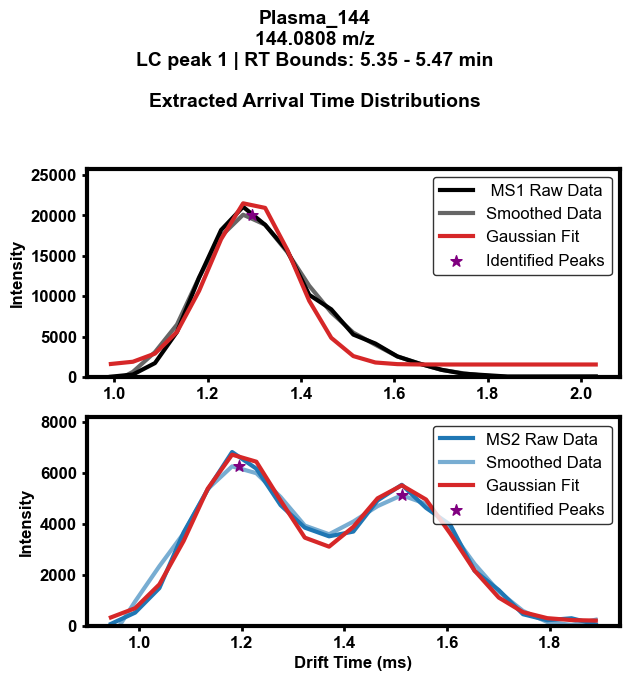

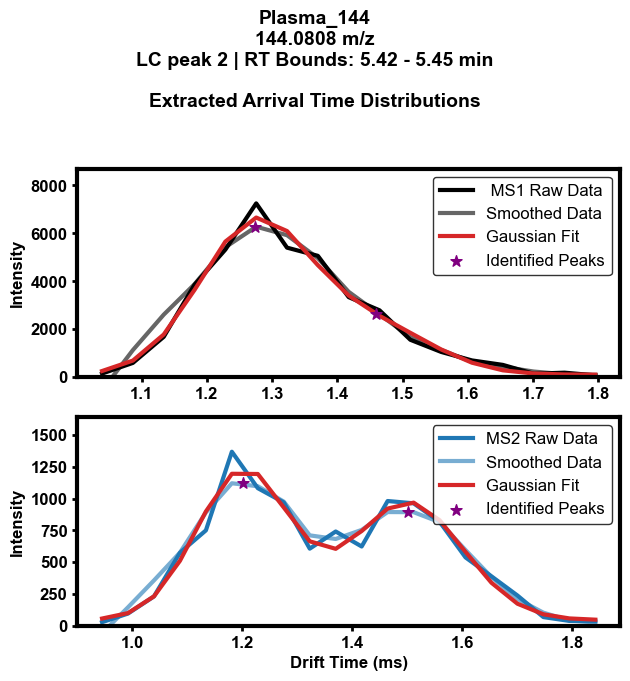

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import savgol_filter

rcParams["font.family"] = "Arial"

def _apply_axis_style(ax):
    ax.tick_params(axis="both", which="major", labelsize=10, width=2)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontweight("bold")
        lab.set_fontsize(12)
    ax.spines["top"].set_linewidth(3)
    ax.spines["right"].set_linewidth(3)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)

def _safe_savgol(y, window, poly):
    y = np.asarray(y, float)
    if y.size < 7:
        return y
    w = int(window)
    if w % 2 == 0:
        w += 1
    w = min(w, y.size if y.size % 2 == 1 else y.size - 1)
    w = max(w, 7)
    p = min(int(poly), w - 1)
    return savgol_filter(y, window_length=w, polyorder=p, mode="interp")

def plot_atd_raw_smooth_fit_peaks_for_feature(
    instances_df,
    atd_store,
    feature_name,
    ms2_mode="ms2_same_mz",
    lc_peak_index=None,
    row_index=None,
    use_fit_store_if_available=True,
    atd_fit_store=None, # Optional
    sg_window=7,
    sg_poly=2,
    peak_marker="*",
    peak_marker_size=90,
    raw_lw=1,
    smooth_lw=3,
    fit_lw=3,
):
    # Filter instances for this feature
    df = instances_df[instances_df["feature_name"].astype(str) == str(feature_name)].copy()
    if df.empty:
        raise ValueError(f"No instances found for feature_name='{feature_name}'")

    if row_index is not None:
        df = df[df["row_index"] == row_index].copy()
        if df.empty:
            raise ValueError(f"No instances found for feature_name='{feature_name}' with row_index={row_index}")

    if lc_peak_index is not None:
        df = df[df["lc_peak_index"] == lc_peak_index].copy()
        if df.empty:
            raise ValueError(
                f"No instances found for feature_name='{feature_name}' with lc_peak_index={lc_peak_index} "
                f"(and row_index={row_index})."
            )

    df = df.sort_values(["row_index", "lc_peak_index"]).reset_index(drop=True)

    # Loop through LC peaks and plot one figure per LC peak 
    for _, inst in df.iterrows():
        key = (int(inst["row_index"]), int(inst["lc_peak_index"]))
        if key not in atd_store:
            print(f"Missing ATD data for key={key} (skipping)")
            continue

        d = atd_store[key]

        # Grab raw traces
        ms1_dt = np.asarray(d.get("ms1_dt", []), float)
        ms1_y  = np.asarray(d.get("ms1_atd", []), float)

        ms2_dt = np.asarray(d.get(f"{ms2_mode}_dt", []), float)
        ms2_y  = np.asarray(d.get(f"{ms2_mode}_atd", []), float)

        # Smooth for plotting
        ms1_s = _safe_savgol(ms1_y, sg_window, sg_poly) if ms1_dt.size else np.array([])
        ms2_s = _safe_savgol(ms2_y, sg_window, sg_poly) if ms2_dt.size else np.array([])

        # Pull fit from store if available, else fit on the fly 
        ms1_fit = None
        ms2_fit = None

        if use_fit_store_if_available and (atd_fit_store is not None) and (key in atd_fit_store):
            ms1_fit = atd_fit_store[key].get("ms1", None)
            ms2_fit = atd_fit_store[key].get("ms2", None)  # Store uses "ms2" entry 

        # If not present, fit now 
        if ms1_fit is None and ms1_dt.size:
            centers, _, _, _ = second_derivative_peak_centers(ms1_dt, ms1_y, sg_window=sg_window, sg_poly=sg_poly)
            ms1_fit = fit_atd_multi_gaussian(ms1_dt, ms1_y, centers, include_baseline=True)

        if ms2_fit is None and ms2_dt.size:
            centers, _, _, _ = second_derivative_peak_centers(ms2_dt, ms2_y, sg_window=sg_window, sg_poly=sg_poly)
            ms2_fit = fit_atd_multi_gaussian(ms2_dt, ms2_y, centers, include_baseline=True)

        # Extract fitted mu values for markers 
        ms1_mu = np.array([p["mu"] for p in ms1_fit["peaks"]]) if (ms1_fit and ms1_fit.get("success")) else np.array([])
        ms2_mu = np.array([p["mu"] for p in ms2_fit["peaks"]]) if (ms2_fit and ms2_fit.get("success")) else np.array([])

        # y-value for markers = smoothed intensity at nearest dt index
        def _marker_y(dt, y_s, mu_list):
            ys = []
            for mu in mu_list:
                i = int(np.argmin(np.abs(dt - mu)))
                ys.append(float(y_s[i]) if y_s.size else np.nan)
            return np.array(ys, float)

        # Set up figure
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6.4, 6.9), sharex=False)

        # Title
        fig.suptitle(
            f"{inst['feature_name']}\n"
            f"{inst['target_mz']:.4f} m/z\n"
            f"LC peak {int(inst['lc_peak_index'])} | RT Bounds: {inst['rt_left']:.2f} - {inst['rt_right']:.2f} min\n\n"
            f"Extracted Arrival Time Distributions",
            fontsize=14,
            fontweight="bold",
            y=0.98
        )

        # MS1 subplot
        if ms1_dt.size:
            ax1.plot(ms1_dt, ms1_y, lw=raw_lw, color="black", label=" MS1 Raw Data")
            ax1.plot(ms1_dt, ms1_s, lw=smooth_lw, color="black", alpha=0.6, label="Smoothed Data")

            if ms1_fit and ms1_fit.get("success"):
                ax1.plot(ms1_dt, ms1_fit["yfit"], lw=fit_lw, color="tab:red", label="Gaussian Fit")

            if ms1_mu.size:
                ax1.scatter(
                    ms1_mu,
                    _marker_y(ms1_dt, ms1_s, ms1_mu),
                    marker=peak_marker,
                    s=peak_marker_size,
                    color="purple",
                    label="Identified Peaks",
                    zorder=5
                )
        else:
            ax1.text(0.5, 0.5, "No MS1 ATD", ha="center", va="center", transform=ax1.transAxes)

        ax1.set_ylabel("Intensity", fontsize=12, fontweight="bold")
        # ax1.set_title("MS1 ATD", fontsize=12, fontweight="bold")
        _apply_axis_style(ax1)
        ax1.legend(loc="best", frameon=True, fontsize=12, edgecolor="black", facecolor="white")

        # MS2 subplot
        if ms2_dt.size:
            ax2.plot(ms2_dt, ms2_y, lw=raw_lw, color="tab:blue", label="MS2 Raw Data")
            ax2.plot(ms2_dt, ms2_s, lw=smooth_lw, color="tab:blue", alpha=0.6, label="Smoothed Data")

            if ms2_fit and ms2_fit.get("success"):
                ax2.plot(ms2_dt, ms2_fit["yfit"], lw=fit_lw, color="tab:red", label="Gaussian Fit")

            if ms2_mu.size:
                ax2.scatter(
                    ms2_mu,
                    _marker_y(ms2_dt, ms2_s, ms2_mu),
                    marker=peak_marker,
                    s=peak_marker_size,
                    color="purple",
                    label="Identified Peaks",
                    zorder=5
                )
        else:
            ax2.text(0.5, 0.5, f"No MS2 ATD ({ms2_mode})", ha="center", va="center", transform=ax2.transAxes)

        ax2.set_xlabel("Drift Time (ms)", fontsize=12, fontweight="bold")
        ax2.set_ylabel("Intensity", fontsize=12, fontweight="bold")
        # ax2.set_title(f"MS2 ATD ({ms2_mode})", fontsize=12, fontweight="bold")
        _apply_axis_style(ax2)
        ax2.legend(loc="best", frameon=True, fontsize=12, edgecolor="black", facecolor="white")

        # y-lims: set per-axis based on plotted data 
        for ax in (ax1, ax2):
            lines = ax.get_lines()
            if lines:
                y_max = max(float(np.max(ln.get_ydata())) for ln in lines if ln.get_ydata().size)
                ax.set_ylim(0, y_max * 1.2 if y_max > 0 else 1)

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()

# Run 
plot_atd_raw_smooth_fit_peaks_for_feature(
    instances_df=instances_df,
    atd_store=atd_store,
    feature_name=FEATURE_NAME,
    ms2_mode=MS2_MODE,
    lc_peak_index=LC_PEAK_INDEX,
    row_index=ROW_INDEX,
    use_fit_store_if_available=USE_FIT_STORE_IF_AVAILABLE,
    atd_fit_store=(atd_fit_store if "atd_fit_store" in globals() else None),
    sg_window=SG_WINDOW,
    sg_poly=SG_POLY,
    peak_marker=PEAK_MARKER,
    peak_marker_size=PEAK_MARKER_SIZE,
    raw_lw=RAW_LW,
    smooth_lw=SMOOTH_LW,
    fit_lw=FIT_LW,
)

##### (11) Identification of candidate in-source fragments (ISFs) based on MS1 and MS2 ATD alignment

##### Edit the code below to tune tolerance parameters for MS1-MS2 peak alignment

In [24]:
# Drift time offset in ms between MS1 and MS2 space
# This phenomenon arises from the fact that MS2 ions travel faster than the corresponding MS1 ions under higher voltage 
# Currently, the offset value must be hard-set; this is a flawed assumption because the offset is dependent on voltage and mass
# For now, a hard-set value is operationally acceptable
DEIMOS_DT_OFFSET_MS = 0.1 # Recommended: 0.1-0.15

# Offset sign convention 
# True assummes that MS2 ions always travel faster under higher voltage than the corresponding MS1 ions 
# Only set to False if this assumption does not hold
OFFSET_MAPS_MS2_TO_MS1 = True # Recommended: True

# Drift time alignment tolerances 
ABS_ALIGN_TOL_MS = 0.03 # Absolute floor tolerance in ms; recommended: 0.02–0.05
K_WIDTH = 0.30 # Scale factor applied to peak width; recommended: 0.25–0.50

# Presence thresholds for MS1 fragment 
MIN_REL_TO_MAX_ATD = 0.01 # Recommended: 0.01 (e.g., 1% of max ATD intensity)
MIN_ABS_A = None # Recommended: None

# Offset sign convention 
OFFSET_MAPS_MS2_TO_MS1 = True # Recommended: True

# OPTIONAL: only run alignment for a single feature name 
FEATURE_NAME_FILTER = None # Set to None to align all features 

# Printing and debugging 
VERBOSE = True # Recommended to keep True for tracking and debugging 

##### Run the cell below to identify ISF candidates

In [25]:
import numpy as np
import pandas as pd

MS2_LEVEL = "ms2_same_mz"

def ms1_fragment_present_from_peaks(ms1_peaks_df, ms1_y, min_rel_to_max_atd=0.01, min_abs_A=None):
    if ms1_peaks_df is None or ms1_peaks_df.empty:
        return False, "MS1 peaks missing"

    y_max = float(np.max(ms1_y)) if (ms1_y is not None and len(ms1_y) > 0) else 0.0
    if y_max <= 0:
        return False, "MS1 ATD max intensity <= 0"

    A_max = float(ms1_peaks_df["A"].max())

    if min_abs_A is not None and A_max < float(min_abs_A):
        return False, f"MS1 A_max={A_max:.3g} < min_abs_A={min_abs_A}"

    if A_max < float(min_rel_to_max_atd) * y_max:
        return False, f"MS1 A_max={A_max:.3g} < {min_rel_to_max_atd:.3g} * max(ATD)={y_max:.3g}"

    return True, "MS1 fragment present"

def label_ms2_alignment_widthaware_from_peaksdf(
    ms1_peaks_df,
    ms2_peaks_df,
    dt_offset_ms,
    abs_align_tol_ms=0.03,
    k_width=0.30,
    offset_maps_ms2_to_ms1=True,
):
    if ms2_peaks_df is None or ms2_peaks_df.empty:
        return pd.DataFrame(columns=[
            "A","mu","sigma","FWHM",
            "mu_ms2_to_ms1","nearest_ms1_mu","delta_to_nearest_ms1",
            "aligned_to_ms1_component","alignment_label",
            "width_term_ms","align_tol_ms_used"
        ])

    ms2 = ms2_peaks_df.copy()
    ms1 = ms1_peaks_df.copy() if (ms1_peaks_df is not None) else pd.DataFrame()

    shift = float(dt_offset_ms) if offset_maps_ms2_to_ms1 else -float(dt_offset_ms)
    ms2["mu_ms2_to_ms1"] = ms2["mu"].astype(float) + shift

    if ms1.empty:
        ms2["nearest_ms1_mu"] = np.nan
        ms2["delta_to_nearest_ms1"] = np.nan
        ms2["width_term_ms"] = np.nan
        ms2["align_tol_ms_used"] = float(abs_align_tol_ms)
        ms2["aligned_to_ms1_component"] = np.nan
        ms2["alignment_label"] = "unaligned"
        return ms2

    ms1_mus = ms1["mu"].to_numpy(float)
    ms1_fwhm = ms1["FWHM"].to_numpy(float)
    ms2_fwhm = ms2["FWHM"].to_numpy(float)

    nearest_mu, deltas, nearest_idx, width_term, tol_used = [], [], [], [], []

    for i, mu_mapped in enumerate(ms2["mu_ms2_to_ms1"].to_numpy(float)):
        j = int(np.argmin(np.abs(ms1_mus - mu_mapped)))

        nearest_idx.append(j)
        nearest_mu.append(float(ms1_mus[j]))

        delta = float(abs(ms1_mus[j] - mu_mapped))
        deltas.append(delta)

        f1 = float(ms1_fwhm[j]) if np.isfinite(ms1_fwhm[j]) else np.nan
        f2 = float(ms2_fwhm[i]) if np.isfinite(ms2_fwhm[i]) else np.nan

        if np.isfinite(f1) and np.isfinite(f2) and f1 > 0 and f2 > 0:
            wterm = float(k_width) * min(f1, f2)
        else:
            wterm = 0.0

        width_term.append(wterm)
        tol_used.append(max(float(abs_align_tol_ms), wterm))

    ms2["nearest_ms1_mu"] = nearest_mu
    ms2["delta_to_nearest_ms1"] = deltas
    ms2["width_term_ms"] = width_term
    ms2["align_tol_ms_used"] = tol_used

    aligned = ms2["delta_to_nearest_ms1"] <= ms2["align_tol_ms_used"]
    ms2["aligned_to_ms1_component"] = np.where(aligned, nearest_idx, np.nan)
    ms2["alignment_label"] = np.where(aligned, "aligned", "unaligned")

    return ms2

def run_alignment_all_from_peaks_df(
    peaks_df,
    instances_df,
    atd_store,
    ms2_level="ms2_same_mz",
    dt_offset_ms=0.10,
    abs_align_tol_ms=0.03,
    k_width=0.30,
    offset_maps_ms2_to_ms1=True,
    min_rel_to_max_atd=0.01,
    min_abs_A=None,
    feature_name_filter=None,
    verbose=True,
):
    """
    For each (row_index, lc_peak_index), compare MS2_LEVEL peaks against MS1 peaks.
    Returns one row per MS2 peak with alignment_label.
    """

    # Optional filter by feature name 
    if feature_name_filter is not None:
        peaks_df_use = peaks_df[peaks_df["feature_name"].astype(str) == str(feature_name_filter)].copy()
    else:
        peaks_df_use = peaks_df.copy()

    # Keep only successful fits
    peaks_df_use = peaks_df_use[peaks_df_use["fit_success"] == True].copy()

    out_rows = []
    n_groups = 0
    n_skipped_missing_levels = 0
    n_skipped_missing_atd = 0
    n_skipped_ms1_not_present = 0

    for (row_idx, lc_idx), g in peaks_df_use.groupby(["row_index", "lc_peak_index"], sort=False):
        n_groups += 1

        ms1_peaks = g[g["level"] == "ms1"][["A","mu","sigma","FWHM"]].copy()
        ms2_peaks = g[g["level"] == ms2_level][["A","mu","sigma","FWHM"]].copy()

        if ms1_peaks.empty or ms2_peaks.empty:
            n_skipped_missing_levels += 1
            continue

        key = (int(row_idx), int(lc_idx))
        if key not in atd_store:
            n_skipped_missing_atd += 1
            continue

        ms1_y = np.asarray(atd_store[key].get("ms1_atd", []), float)
        present, _ = ms1_fragment_present_from_peaks(
            ms1_peaks, ms1_y,
            min_rel_to_max_atd=min_rel_to_max_atd,
            min_abs_A=min_abs_A
        )
        if not present:
            n_skipped_ms1_not_present += 1
            continue

        labeled_ms2 = label_ms2_alignment_widthaware_from_peaksdf(
            ms1_peaks_df=ms1_peaks,
            ms2_peaks_df=ms2_peaks,
            dt_offset_ms=dt_offset_ms,
            abs_align_tol_ms=abs_align_tol_ms,
            k_width=k_width,
            offset_maps_ms2_to_ms1=offset_maps_ms2_to_ms1,
        )

        # Pull instance metadata 
        inst_match = instances_df[
            (instances_df["row_index"] == row_idx) &
            (instances_df["lc_peak_index"] == lc_idx)
        ]
        if not inst_match.empty:
            inst = inst_match.iloc[0]
            feature_name = inst.get("feature_name", None)
            target_mz = float(inst.get("target_mz", np.nan))
            rt_left = float(inst.get("rt_left", np.nan))
            rt_right = float(inst.get("rt_right", np.nan))
        else:
            feature_name = None
            target_mz = np.nan
            rt_left = np.nan
            rt_right = np.nan

        for _, r in labeled_ms2.iterrows():
            out_rows.append({
                "row_index": int(row_idx),
                "lc_peak_index": int(lc_idx),
                "feature_name": feature_name,
                "target_mz": target_mz,
                "rt_left": rt_left,
                "rt_right": rt_right,

                "A": float(r.get("A", np.nan)),
                "mu": float(r.get("mu", np.nan)),
                "sigma": float(r.get("sigma", np.nan)),
                "FWHM": float(r.get("FWHM", np.nan)),

                "mu_ms2_to_ms1": float(r.get("mu_ms2_to_ms1", np.nan)),
                "nearest_ms1_mu": float(r.get("nearest_ms1_mu", np.nan)),
                "delta_to_nearest_ms1": float(r.get("delta_to_nearest_ms1", np.nan)),
                # "aligned_to_ms1_component": r.get("aligned_to_ms1_component", np.nan),
                "alignment_label": r.get("alignment_label", None),

                # Optional debug columns 
                # "width_term_ms": float(r.get("width_term_ms", np.nan)),
                # "align_tol_ms_used": float(r.get("align_tol_ms_used", np.nan)),
            })

    out_df = pd.DataFrame(out_rows)

    if verbose:
        print("ATD alignment complete.")
        print(f"  groups:                          {n_groups}")
        print(f"  skipped (missing ms1/ms2 level): {n_skipped_missing_levels}")
        print(f"  skipped (missing atd_store):     {n_skipped_missing_atd}")
        print(f"  skipped (MS1 not present):       {n_skipped_ms1_not_present}")
        print(f"  output MS2 peak rows:            {len(out_df)}")
        if len(out_df) and ("align_tol_ms_used" in out_df.columns):
            print(f"  align_tol_ms_used range:         {out_df['align_tol_ms_used'].min():.4f}–{out_df['align_tol_ms_used'].max():.4f} ms")

    return out_df

# Run
ms2_alignment_all_df = run_alignment_all_from_peaks_df(
    peaks_df=peaks_df,
    instances_df=instances_df,
    atd_store=atd_store,
    ms2_level=MS2_LEVEL,
    dt_offset_ms=DEIMOS_DT_OFFSET_MS,
    abs_align_tol_ms=ABS_ALIGN_TOL_MS,
    k_width=K_WIDTH,
    offset_maps_ms2_to_ms1=OFFSET_MAPS_MS2_TO_MS1,
    min_rel_to_max_atd=MIN_REL_TO_MAX_ATD,
    min_abs_A=MIN_ABS_A,
    feature_name_filter=FEATURE_NAME_FILTER,
    verbose=VERBOSE,
)

display(ms2_alignment_all_df.head(30))

ATD alignment complete.
  groups:                          2
  skipped (missing ms1/ms2 level): 0
  skipped (missing atd_store):     0
  skipped (MS1 not present):       0
  output MS2 peak rows:            4


,row_index,lc_peak_index,feature_name,target_mz,rt_left,rt_right,A,mu,sigma,FWHM,mu_ms2_to_ms1,nearest_ms1_mu,delta_to_nearest_ms1,alignment_label
0,0,1,Plasma_144,144.0808,5.346933,5.466933,6581.441154,1.195514,0.089179,0.210000,1.295514,1.294513,0.001001,aligned
1,0,1,Plasma_144,144.0808,5.346933,5.466933,5302.608264,1.512465,0.100336,0.236274,1.612465,1.294513,0.317952,unaligned
2,0,2,Plasma_144,144.0808,5.416933,5.446933,1181.942240,1.202358,0.084735,0.199536,1.302358,1.274388,0.027969,aligned
3,0,2,Plasma_144,144.0808,5.416933,5.446933,927.937973,1.501469,0.100336,0.236274,1.601469,1.459252,0.142218,unaligned


##### (12) Extract the set of candidate MS1 ions associated with each ISF candidate

In [26]:
import numpy as np
import pandas as pd

# Choose alignment table automatically
if "ms2_alignment_all_df" in globals():
    ALIGNMENT_DF = ms2_alignment_all_df
elif "ms2_alignment_df" in globals():
    ALIGNMENT_DF = ms2_alignment_df
else:
    raise NameError("Could not find ms2_alignment_all_df or ms2_alignment_df in globals().")

if "ms_data" not in globals():
    raise NameError("Could not find ms_data in globals(). Make sure you ran the H5 loading cell.")

# Constants; the user should not have to define these prior 
DT_HALF_WIDTH_FACTOR = 0.5   # Drift time window = mu ± 0.5*FWHM; may need to be adjusted for overlapping peaks
MZ_MIN = None
MZ_MAX = None

def _infer_file_key_for_instance(inst_row: pd.Series) -> str:
    """
    Try common columns that may exist in instances_df to find the file stem/key that matches ms_data.
    Returns a key that must exist in ms_data.
    """
    candidates = []

    # Column names 
    for col in ["file_stem", "file_key", "h5_stem", "stem", "file_name", "File Name", "h5_path", "path"]:
        if col in inst_row.index and pd.notna(inst_row[col]):
            candidates.append(str(inst_row[col]))

    # Try to normalize candidate strings into a ms_data key
    for c in candidates:

        # If it's a path, take stem
        try:
            from pathlib import Path
            p = Path(c)
            if p.suffix.lower() == ".h5":
                key = p.stem
            else:
                key = p.with_suffix("").name
        except Exception:
            key = c

        # Strip trailing .h5 if present
        if key.lower().endswith(".h5"):
            key = key[:-3]

        if key in ms_data:
            return key

    raise KeyError(
        "Could not infer file key for instance. "
        "Please ensure instances_df contains a file identifier (e.g., file_stem or file_name) that matches ms_data keys."
    )

def _extract_ms1_ions_from_df(ms1_df, rt_min, rt_max, dt_min, dt_max, mz_min=None, mz_max=None):
    df = ms1_df[
        (ms1_df["retention_time"] >= rt_min) &
        (ms1_df["retention_time"] <= rt_max) &
        (ms1_df["drift_time"] >= dt_min) &
        (ms1_df["drift_time"] <= dt_max)
    ]
    if mz_min is not None:
        df = df[df["mz"] >= mz_min]
    if mz_max is not None:
        df = df[df["mz"] <= mz_max]
    return df

# MLoop over all unaligned MS2 components and collect MS1 ions
unaligned = ALIGNMENT_DF[ALIGNMENT_DF["alignment_label"] == "unaligned"].copy()
print(f"Unaligned MS2 ATD components: {len(unaligned)}")

# Need these columns in alignment_df
need = ["row_index", "lc_peak_index", "mu_ms2_to_ms1", "FWHM"]
missing = [c for c in need if c not in unaligned.columns]
if missing:
    raise ValueError(f"ALIGNMENT_DF missing required columns: {missing}")

ms1_ions_rows = []
summary_rows = []

# Use instances_df to pull RT and file key 
for comp_i, r in unaligned.reset_index(drop=True).iterrows():
    row_index = int(r["row_index"])
    lc_peak_index = int(r["lc_peak_index"])

    # Find the matching instance row 
    inst_match = instances_df[
        (instances_df["row_index"] == row_index) &
        (instances_df["lc_peak_index"] == lc_peak_index)
    ]
    if inst_match.empty:
    
        continue
    inst = inst_match.iloc[0]

    file_key = _infer_file_key_for_instance(inst)
    ms1_df = ms_data[file_key]["ms1"]

    # RT window
    if "rt_left" in inst.index and "rt_right" in inst.index:
        rt_min = float(inst["rt_left"])
        rt_max = float(inst["rt_right"])
    elif "rt_left" in r.index and "rt_right" in r.index and pd.notna(r["rt_left"]) and pd.notna(r["rt_right"]):
        rt_min = float(r["rt_left"])
        rt_max = float(r["rt_right"])
    else:
        raise KeyError("Could not find rt_left/rt_right in instances_df (or ALIGNMENT_DF fallback).")

    # DT window from mapped MS2 component
    mu = float(r["mu_ms2_to_ms1"])
    fwhm = float(r["FWHM"]) if np.isfinite(r["FWHM"]) else np.nan
    if not np.isfinite(mu) or not np.isfinite(fwhm) or fwhm <= 0:
        continue

    dt_min = mu - DT_HALF_WIDTH_FACTOR * fwhm
    dt_max = mu + DT_HALF_WIDTH_FACTOR * fwhm

    ms1_spec = _extract_ms1_ions_from_df(
        ms1_df,
        rt_min=rt_min, rt_max=rt_max,
        dt_min=dt_min, dt_max=dt_max,
        mz_min=MZ_MIN, mz_max=MZ_MAX
    )

    summary_rows.append({
        "component_index": comp_i,
        "file_key": file_key,
        "row_index": row_index,
        "lc_peak_index": lc_peak_index,
        "feature_name": inst.get("feature_name", None),
        "target_mz": float(inst.get("target_mz", np.nan)),
        "rt_left": rt_min,
        "rt_right": rt_max,
        "mu_ms2_to_ms1": mu,
        "FWHM": fwhm,
        "dt_left": dt_min,
        "dt_right": dt_max,
        "n_ms1_rows": int(len(ms1_spec)),
        "n_ms1_unique_mz": int(ms1_spec["mz"].nunique()) if not ms1_spec.empty else 0,
    })

    if not ms1_spec.empty:
        tmp = ms1_spec.copy()
        tmp["component_index"] = comp_i
        tmp["file_key"] = file_key
        tmp["row_index"] = row_index
        tmp["lc_peak_index"] = lc_peak_index
        tmp["feature_name"] = inst.get("feature_name", None)
        tmp["target_mz"] = float(inst.get("target_mz", np.nan))
        tmp["rt_left"] = rt_min
        tmp["rt_right"] = rt_max
        tmp["dt_left"] = dt_min
        tmp["dt_right"] = dt_max
        tmp["mu_ms2_to_ms1"] = mu
        tmp["FWHM_ms2"] = fwhm

        ms1_ions_rows.append(tmp)

# Outputs
unaligned_components_summary_df = pd.DataFrame(summary_rows)
ms1_ions_all_df = pd.concat(ms1_ions_rows, ignore_index=True) if ms1_ions_rows else pd.DataFrame()

print("unaligned_components_summary_df:", unaligned_components_summary_df.shape)
print("ms1_ions_all_df:", ms1_ions_all_df.shape)

display(unaligned_components_summary_df.head(20))
# display(ms1_ions_all_df.head(20))

Unaligned MS2 ATD components: 2
unaligned_components_summary_df: (2, 14)
ms1_ions_all_df: (927, 19)


,component_index,file_key,row_index,lc_peak_index,feature_name,target_mz,rt_left,rt_right,mu_ms2_to_ms1,FWHM,dt_left,dt_right,n_ms1_rows,n_ms1_unique_mz
0,0,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.612465,0.236274,1.494328,1.730602,728,349
1,1,Plasma_203_HDMSE,0,2,Plasma_144,144.0808,5.416933,5.446933,1.601469,0.236274,1.483332,1.719606,199,121


##### Visualize the set of candidate MS1 ions associated with a selected ISF candidate

In [31]:
# Pick one row from unaligned_components_summary_df (above) to plot
COMPONENT_INDEX = 1

# Choose how many ions (ranked by intensity) to plot 
TOP_N_IONS = 10

# OPTIONAL: restrict to an m/z window 
MZ_MIN_PLOT = None
MZ_MAX_PLOT = None

##### Run the cell below to generate MS1 spectrum plot

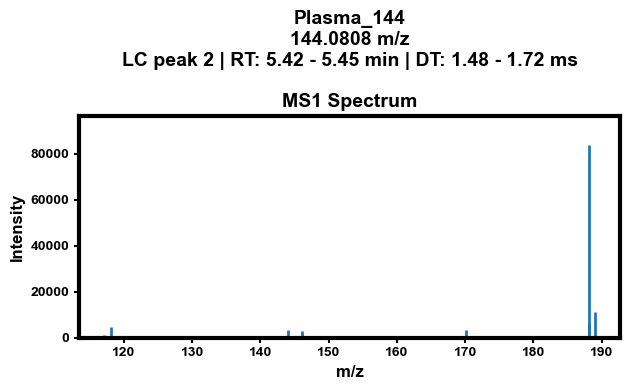

Top 10 ions:


,mz,intensity
0,188.072083,84106.0
1,189.072128,11234.0
2,188.067261,6262.0
3,118.064140,4864.0
4,144.078964,3547.0
5,170.061432,3212.0
6,146.057755,3039.0
7,146.062012,1597.0
8,189.076965,1339.0
9,117.057137,1169.0


'from pathlib import Path\n\n# Output directory for spectra tables\nOUT_XLSX_DIR = Path("Filtered Spectra")\nOUT_XLSX_DIR.mkdir(parents=True, exist_ok=True)\n\n# Construct filename\nxlsx_path = OUT_XLSX_DIR / (\n    f"MS1_top{TOP_N_IONS}_ions_"\n    f"component{COMPONENT_INDEX}_"\n    f"LCpeak{int(meta.get(\'lc_peak_index\'))}.xlsx"\n)\n\n# Write to Excel\ntopN_df.to_excel(\n    xlsx_path,\n    index=False,\n    engine="openpyxl"\n)'

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"] = "Arial"

def _apply_axis_style(ax):
    ax.tick_params(axis="both", which="major", labelsize=10, width=1.5)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontweight("bold")
        lab.set_fontsize(10)
    ax.spines["top"].set_linewidth(3)
    ax.spines["right"].set_linewidth(3)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)

def get_component_ms1_spectrum_df(ms1_ions_all_df, component_index, mz_min=None, mz_max=None):
    """
    Collapse raw MS1 ion rows for one component_index into a centroid-like spectrum.
    """
    df = ms1_ions_all_df[ms1_ions_all_df["component_index"] == component_index].copy()
    if df.empty:
        raise ValueError(f"No MS1 ions found for component_index={component_index}")

    if mz_min is not None:
        df = df[df["mz"] >= float(mz_min)]
    if mz_max is not None:
        df = df[df["mz"] <= float(mz_max)]

    spec = (
        df.groupby("mz", as_index=False)["intensity"]
          .sum()
          .sort_values("intensity", ascending=False)
    )
    return spec

def plot_ms1_spectrum_atd_style(
    spec_df,
    title,
    top_n=50
):
    if spec_df.empty:
        print("Empty spectrum after filtering.")
        return

    plot_df = spec_df.head(int(top_n)).sort_values("mz").copy()

    fig, ax = plt.subplots(figsize=(6.4, 4))

    # Stick plot 
    ax.vlines(plot_df["mz"].to_numpy(float), 0, plot_df["intensity"].to_numpy(float), linewidth=2)

    ax.set_xlabel("m/z", fontsize=12, fontweight="bold")
    ax.set_ylabel("Intensity", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold")

    _apply_axis_style(ax)

    # y-axis 
    y_max = float(plot_df["intensity"].max()) if len(plot_df) else 1.0
    ax.set_ylim(0, y_max * 1.15 if y_max > 0 else 1.0)

    plt.tight_layout()
    plt.show()

if "unaligned_components_summary_df" not in globals():
    raise NameError("unaligned_components_summary_df not found. Run the MS1-ion extraction cell first.")
if "ms1_ions_all_df" not in globals():
    raise NameError("ms1_ions_all_df not found. Run the MS1-ion extraction cell first.")

meta = unaligned_components_summary_df[
    unaligned_components_summary_df["component_index"] == COMPONENT_INDEX
]
if meta.empty:
    raise ValueError(
        f"component_index={COMPONENT_INDEX} not found. "
        f"Valid examples: {unaligned_components_summary_df['component_index'].head(10).tolist()}"
    )
meta = meta.iloc[0]

# Build spectrum and output mass, intensity table 
spec_df = get_component_ms1_spectrum_df(
    ms1_ions_all_df=ms1_ions_all_df,
    component_index=COMPONENT_INDEX,
    mz_min=MZ_MIN_PLOT,
    mz_max=MZ_MAX_PLOT
)

topN_df = spec_df.head(int(TOP_N_IONS)).copy()
topN_df = topN_df.rename(columns={"intensity": "intensity"}).reset_index(drop=True)

# Plot
title = (
    # f"MS1 spectrum (cast-back) | component {COMPONENT_INDEX}\n"
    f"{meta.get('feature_name', '')}\n"
    f"{float(meta.get('target_mz', np.nan)):.4f} m/z\n"
    f"LC peak {int(meta.get('lc_peak_index'))} | RT: {float(meta.get('rt_left')):.2f} - {float(meta.get('rt_right')):.2f} min | "
    f"DT: {float(meta.get('dt_left')):.2f} - {float(meta.get('dt_right')):.2f} ms\n\n"
    f"MS1 Spectrum"
)

plot_ms1_spectrum_atd_style(
    spec_df=spec_df,
    title=title,
    top_n=TOP_N_IONS
)

print(f"Top {TOP_N_IONS} ions:")
display(topN_df)

# Optional export to Excel
"""from pathlib import Path

# Output directory for spectra tables
OUT_XLSX_DIR = Path("Filtered Spectra")
OUT_XLSX_DIR.mkdir(parents=True, exist_ok=True)

# Construct filename
xlsx_path = OUT_XLSX_DIR / (
    f"MS1_top{TOP_N_IONS}_ions_"
    f"component{COMPONENT_INDEX}_"
    f"LCpeak{int(meta.get('lc_peak_index'))}.xlsx"
)

# Write to Excel
topN_df.to_excel(
    xlsx_path,
    index=False,
    engine="openpyxl"
)"""

##### (13) Identify related features for each ISF candidate using specral deconvolution approach 

##### Edit the cell below to bin the extracted MS1 spectrum for each ISF-related feature

In [33]:
# This is highly recommended to reduce complexity in subsequent deconvolution steps 

# Clustering tolerance in ppm used to bin MS1 ions 
MS1_BIN_PPM = 10.0   # typical: 5–20 ppm (try 10 first)

# OPTIONAL: keep only the top K clusters per component (by summed intensity)
TOP_K_CLUSTERS_PER_COMPONENT = 50  # set None to keep all

# Require at least this many MS1 rows to attempt clustering
MIN_MS1_ROWS_PER_COMPONENT = 1 # Recommended: 1

##### Run the cell below to bin MS1 candidates

In [34]:
import numpy as np
import pandas as pd

def collapse_and_cluster_ms1_spectrum(
    ms1_spec_df: pd.DataFrame,
    ppm_tol: float = 10.0,
    intensity_col: str = "intensity",
    mz_col: str = "mz",
    top_k: int | None = None
) -> pd.DataFrame:
    if ms1_spec_df is None or ms1_spec_df.empty:
        return pd.DataFrame(columns=["cluster_id", "mz_center", "intensity_sum", "n_peaks", "mz_min", "mz_max"])

    # Collapse exact m/z duplicates
    collapsed = (
        ms1_spec_df[[mz_col, intensity_col]]
        .groupby(mz_col, as_index=False)[intensity_col]
        .sum()
        .sort_values(mz_col)
        .reset_index(drop=True)
        .rename(columns={mz_col: "mz", intensity_col: "intensity"})
    )

    mz = collapsed["mz"].to_numpy(float)
    I = collapsed["intensity"].to_numpy(float)

    # Clustering in m/z order using ppm tolerance
    clusters = []
    cluster_id = 0
    start_idx = 0
    mz_max = mz[0]

    def ppm_window(mz_ref):
        delta = (ppm_tol * 1e-6) * mz_ref
        return mz_ref - delta, mz_ref + delta

    for i in range(1, len(mz)):
        _, max_allowed = ppm_window(mz_max)
        if mz[i] <= max_allowed:
            mz_max = mz[i]
        else:
            idxs = np.arange(start_idx, i)
            mz_cluster = mz[idxs]
            I_cluster = I[idxs]
            I_sum = float(I_cluster.sum())
            mz_center = float((mz_cluster * I_cluster).sum() / I_sum) if I_sum > 0 else float(mz_cluster.mean())

            clusters.append({
                "cluster_id": cluster_id,
                "mz_center": mz_center,
                "intensity_sum": I_sum,
                "n_peaks": int(len(idxs)),
                "mz_min": float(mz_cluster.min()),
                "mz_max": float(mz_cluster.max()),
            })
            cluster_id += 1
            start_idx = i
            mz_max = mz[i]

    # Finalize last cluster
    idxs = np.arange(start_idx, len(mz))
    mz_cluster = mz[idxs]
    I_cluster = I[idxs]
    I_sum = float(I_cluster.sum())
    mz_center = float((mz_cluster * I_cluster).sum() / I_sum) if I_sum > 0 else float(mz_cluster.mean())

    clusters.append({
        "cluster_id": cluster_id,
        "mz_center": mz_center,
        "intensity_sum": I_sum,
        "n_peaks": int(len(idxs)),
        "mz_min": float(mz_cluster.min()),
        "mz_max": float(mz_cluster.max()),
    })

    clustered = (
        pd.DataFrame(clusters)
        .sort_values("intensity_sum", ascending=False)
        .reset_index(drop=True)
    )

    if top_k is not None:
        clustered = clustered.head(int(top_k)).copy()

    return clustered

def cluster_ms1_spectra_per_unaligned_component(
    unaligned_components_summary_df: pd.DataFrame,
    ms1_ions_all_df: pd.DataFrame,
    ppm_tol: float = 10.0,
    top_k: int | None = 50,
    min_rows: int = 1,
    verbose: bool = True,
) -> pd.DataFrame:
    if unaligned_components_summary_df is None or unaligned_components_summary_df.empty:
        return pd.DataFrame()

    if ms1_ions_all_df is None or ms1_ions_all_df.empty:
        return pd.DataFrame()

    out = []
    n_total = 0
    n_skipped = 0

    for _, meta in unaligned_components_summary_df.iterrows():
        comp = int(meta["component_index"])
        n_total += 1

        ms1_spec = ms1_ions_all_df[ms1_ions_all_df["component_index"] == comp].copy()
        if len(ms1_spec) < int(min_rows):
            n_skipped += 1
            continue

        clustered = collapse_and_cluster_ms1_spectrum(
            ms1_spec_df=ms1_spec,
            ppm_tol=float(ppm_tol),
            intensity_col="intensity",
            mz_col="mz",
            top_k=top_k
        )

        if clustered.empty:
            n_skipped += 1
            continue

        # Attach metadata 
        clustered.insert(0, "component_index", comp)
        clustered["file_key"] = meta.get("file_key", None)
        clustered["row_index"] = meta.get("row_index", np.nan)
        clustered["lc_peak_index"] = meta.get("lc_peak_index", np.nan)
        clustered["feature_name"] = meta.get("feature_name", None)
        clustered["target_mz"] = meta.get("target_mz", np.nan)
        clustered["rt_left"] = meta.get("rt_left", np.nan)
        clustered["rt_right"] = meta.get("rt_right", np.nan)
        clustered["dt_left"] = meta.get("dt_left", np.nan)
        clustered["dt_right"] = meta.get("dt_right", np.nan)
        clustered["mu_ms2_to_ms1"] = meta.get("mu_ms2_to_ms1", np.nan)
        clustered["FWHM_ms2"] = meta.get("FWHM", np.nan)

        out.append(clustered)

    out_df = pd.concat(out, ignore_index=True) if out else pd.DataFrame()

    if verbose:
        print("MS1 m/z clustering complete.")
        print(f"  components:         {n_total}")
        print(f"  components skipped: {n_skipped}")
        print(f"  cluster rows:       {len(out_df)}")
        if len(out_df):
            print(f"  ppm_tol used:       {ppm_tol}")

    return out_df

# Run
clustered_ms1_all_df = cluster_ms1_spectra_per_unaligned_component(
    unaligned_components_summary_df=unaligned_components_summary_df,
    ms1_ions_all_df=ms1_ions_all_df,
    ppm_tol=MS1_BIN_PPM,
    top_k=TOP_K_CLUSTERS_PER_COMPONENT,
    min_rows=MIN_MS1_ROWS_PER_COMPONENT,
    verbose=True,
)

display(clustered_ms1_all_df.head(25))
print("Unique components clustered:", clustered_ms1_all_df["component_index"].nunique() if len(clustered_ms1_all_df) else 0)

MS1 m/z clustering complete.
  components:         2
  components skipped: 0
  cluster rows:       100
  ppm_tol used:       10.0


,component_index,cluster_id,mz_center,intensity_sum,n_peaks,mz_min,mz_max,file_key,row_index,lc_peak_index,feature_name,target_mz,rt_left,rt_right,dt_left,dt_right,mu_ms2_to_ms1,FWHM_ms2
0,0,52,188.072083,279125.0,1,188.072083,188.072083,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
1,0,57,189.072128,35255.0,1,189.072128,189.072128,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
2,0,51,188.067261,26992.0,1,188.067261,188.067261,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
3,0,7,118.064140,15559.0,1,118.064140,118.064140,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
4,0,22,146.057755,13094.0,1,146.057755,146.057755,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
5,0,16,144.078964,12519.0,1,144.078964,144.078964,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
6,0,44,170.061432,8041.0,1,170.061432,170.061432,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
7,0,58,189.076965,4316.0,1,189.076965,189.076965,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
8,0,5,117.057137,4107.0,1,117.057137,117.057137,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274
9,0,43,170.056839,3996.0,1,170.056839,170.056839,Plasma_203_HDMSE,0,1,Plasma_144,144.0808,5.346933,5.466933,1.494328,1.730602,1.612465,0.236274


Unique components clustered: 2


##### Edit the cell below to tune parameters for spectral deconvolution (DEIMoS)

In [38]:
# DEIMoS configuration variables: these are CRITICAL to the performance of the spectral deconvolution and must be carefully selected
# ALL variables MUST be defined; the default values here have only been tested on experimental Waters LC-IM-HDMSE data (acquired with a Synapt G2 XS mass spectrometer)

from pathlib import Path
import math

# Define how many top clustered MS1 candidates (ranked by intensity) to deconvolute per unaligned component
N_PRECURSOR_CANDS = 5  

# Define name of output spectral library file
OUTPUT_TXT = Path(r"fragtime_demo.txt") 

# If True, the output spectral library file will be OVERWRITTEN if a .txt file with the same name already exist in THE directory
# If False, an error will be thrown if the library file already exists
OVERWRITE_OUTPUT = True 

# Dimensions and relative windows used to connect MS1 and MS2 peaks prior to scoring by drift time profiles
PAIR_DIMS = ["drift_time", "retention_time"] # Dimensions used for pairing MS1 & MS2; recommended to use both DT and RT if available
PAIR_LOW = [-0.12, -0.10] # Lower (relative) offsets from the MS1 center for each PAIR_DIMS dimension (e.g., -0.12 ms and -0.10 s for DT and RT, respectively)
PAIR_HIGH = [1.40, 0.10] # Upper (relative) offsets for each PAIR_DIMS dimension (e.g., +1.40 ms and +0.10 s for DT and RT, respectively)
PAIR_CE = 35 # Collision energy passed into the pairing model; for a ramp, use the midpoint of the values (e.g., 35 for a 25-45 V ramp)
REQUIRE_MS1_GT_MS2 = False # If True, discards MS2 peaks with intensity >= MS1; recommended to keep False in case of very high intense fragments 

# Profile extraction settings for similarity scoring
# DEIMoS extracts intensity profiles along the defined dimensiosn within windows around each MS1 target
# The resulting profiles are then compared by cosine-like similariy to yield drift_time_score (or retention_time_score if desired)
PROF_DIMS = ["mz", "drift_time", "retention_time"] # Dimensions along which profiles may be extracted; recommended to use both DT and RT if available (NOTE: This is computationally expensive)
PROF_LOW = [-200e6, -0.1, -0.10] # Lower (relative) windows around the MS1 center for each PROF_DIMS (e.g., -200e6 Da, -0.10 ms, and -0.10 s for m/z, DT, and RT, respectively)
PROF_HIGH = [600e-6, 0.1, 0.10] # Upper (relative) windows for each PROF_DIMS
PROF_REL = [True, True, True] # Define whether each PROF_DIMS window is treated as relative to the MS1 center.
PROFILE_DIM = "drift_time" # Dimension to score along (the profile axis for similarity)
PROFILE_RES = 0.01 # Bin size for the profile along PROFILE_DIM (e.g., 0.01 drift time units)

# Raw denoising thresholds before peak picking
MS1_THRESH_RAW = 500 # Minimum raw intensity to retain MS1 data points before smoothing/peak-picking; recommended: 500-1000
MS2_THRESH_RAW = 2000 # Minimum raw intensity to retain MS2 data points; recommended: 1000-2000

# Smoothing and peak picking parameters
# Smoothing radius per dimension; number of iterations for each MS tier
# These default values appear to be working; recommended NOT to change
SMOOTH_RADIUS = {'mz':0, 'drift_time':1, 'retention_time':0} # Smoothing radius per dimension 
SMOOTH_ITER_MS1 = 7 # Number of iterations for MS1 tier
SMOOTH_ITER_MS2 = 5 # Number of iterations for MS2 tier

# Peak-picking neighborhood radius per dimension 
# These default values appear to be working; recommended NOT to change
PK_RADIUS = {'mz':2, 'drift_time':10, 'retention_time':0}
PK_RADIUS_MS2 = {'mz':1, 'drift_time':8, 'retention_time':0}  

# Feature-level gating after peak picking
MS1_FEAT_MIN = 1e4 # Primary minimum MS1 peak intensity to consider an MS1 target for deconvolution

# Fallback MS1 intensity threshold; if no candidates pass MS1_FEAT_MIN and this value is not None, the code will fallback to this lower threshold
# Set to None to disable fallback behavior (not recommended)
MS1_FEAT_MIN_FALLBACK = 2e3  # Fallback MS1 intensity threshold
MS2_FEAT_MIN = 2e3 # Minimum MS2 peak intensity to include in candidate MS2 peak set

# Exclude MS2 peaks whose m/z is more than this many Da above the precursor m/z
# Fragments can be assumed to have lower m/z values than MS1 feature 
MS2_MAX_MZ_DELTA = 0.0

# Profile similarity scoring
DT_SCORE_MIN = 0.8 # Minimum profile similarity (e.g., cosine-like) along PROFILE_DIM to keep a putative pair; recommended: 0.8
TOP_N = 2 # For each MS1 target, export at most the top N MS1 groups after scoring and aggregation

# Mass tolerances
MZ_TOL_PPM = 50 # Mass tolerance (ppm) for selecting MS1 targets near the user-defined precursor m/z
MZ_PAIR_ABS = 0.01 # Absolute fallback window for m/z-only pairing when PAIR_DIMS don’t intersect

# Debugging and diagnostics
# Global switch for writing debug artifacts 
DUMP_DEBUG = True # Set to False to disable all outputs; recommended False unless testing 

# Folder where debug files are written when DUMP_DEBUG is True
DEBUG_DIR = Path("DEIMoS Debugging")
DEBUG_DIR.mkdir(exist_ok=True)
DEBUG_DIR = DEBUG_DIR.resolve() # Use absolute path so logs always show where files landed

# Optional tracker to follow a single fragment feature during the deconvolution process
# Set to None to disable fragment tracking entirely
DEBUG_WATCH_FRAG_MZ = 576.4019 # Fragment m/z of interest
DEBUG_FRAG_PPM = 20 # Mass tolerance window (ppm) for the tracked fragment

# Printing and debugging 
VERBOSE = True # Recommended to keep True for tracking and debugging 

##### Run the cell below to deconvolve LC-IM-HDMSE spectra and recover ISF-parent ion relationships 

In [39]:
from pathlib import Path
import math
import traceback
import numpy as np
import pandas as pd
import re

# Define required inputs from clustered_ms1_all_df 
required_cluster_cols = [
    "component_index","cluster_id","mz_center","intensity_sum","n_peaks","mz_min","mz_max",
    "file_key","row_index","lc_peak_index","feature_name","target_mz",
    "rt_left","rt_right","dt_left","dt_right","mu_ms2_to_ms1","FWHM_ms2"
]
missing = [c for c in required_cluster_cols if c not in clustered_ms1_all_df.columns]
if missing:
    raise ValueError(f"clustered_ms1_all_df is missing required columns: {missing}")

# Extract input_sheet and h5_dir from ms_tables 
# If re-defined above, overrides ms_tables entries 
def _coerce_path(x):
    if x is None:
        return None
    try:
        return x if isinstance(x, Path) else Path(str(x))
    except Exception:
        return None

def _extract_input_sheet_and_h5_dir(ms_tables_obj):
    if ms_tables_obj is None:
        return None, None

    # Direct keys 
    if isinstance(ms_tables_obj, dict):
        for k_inp in ["input_sheet", "INPUT_SHEET", "targets_xlsx", "TARGETS_XLSX"]:
            if k_inp in ms_tables_obj:
                inp = _coerce_path(ms_tables_obj.get(k_inp))
                if inp is not None:
                    break
        else:
            inp = None

        for k_h5 in ["h5_dir", "H5_DIR", "h5_directory", "H5_DIRECTORY"]:
            if k_h5 in ms_tables_obj:
                h5d = _coerce_path(ms_tables_obj.get(k_h5))
                if h5d is not None:
                    break
        else:
            h5d = None

        # Infer H5_DIR from any h5_path entries
        if h5d is None:
            sample = None

            # Dictionary of dictionaries 
            for v in ms_tables_obj.values():
                if isinstance(v, dict) and ("h5_path" in v or "H5_PATH" in v):
                    sample = v.get("h5_path", v.get("H5_PATH"))
                    break
            if sample is not None:
                p = _coerce_path(sample)
                if p is not None:
                    h5d = p.parent

        return inp, h5d

    # List of dictionaries 
    if isinstance(ms_tables_obj, (list, tuple)):
        for v in ms_tables_obj:
            if isinstance(v, dict) and ("h5_path" in v or "H5_PATH" in v):
                p = _coerce_path(v.get("h5_path", v.get("H5_PATH")))
                if p is not None:
                    return None, p.parent
        return None, None

    return None, None

# Try to infer
ms_tables_obj = globals().get("ms_tables", None)

if "INPUT_SHEET" not in globals() or globals().get("INPUT_SHEET") is None:
    inp, _ = _extract_input_sheet_and_h5_dir(ms_tables_obj)
    if inp is not None:
        INPUT_SHEET = inp

if "H5_DIR" not in globals() or globals().get("H5_DIR") is None:
    _, h5d = _extract_input_sheet_and_h5_dir(ms_tables_obj)
    if h5d is not None:
        H5_DIR = h5d

# Check
if "H5_DIR" not in globals() or H5_DIR is None:
    raise ValueError("H5_DIR is not defined and could not be inferred from ms_tables.")
H5_DIR = _coerce_path(H5_DIR)
if not H5_DIR.exists():
    raise FileNotFoundError(f"H5_DIR does not exist: {H5_DIR}")

# INPUT_SHEET is optional for deconvolution 
INPUT_SHEET = _coerce_path(globals().get("INPUT_SHEET", None))
if INPUT_SHEET is not None and not INPUT_SHEET.exists():
    print(f"WARNING: INPUT_SHEET was set but does not exist: {INPUT_SHEET}. Proceeding without metadata.")

# Import user settings for configuration variables 
TOP_N_CANDS_PER_COMPONENT = int(globals().get("N_PRECURSOR_CANDS", 5))  
DECONVOLVE_TARGET_MZ_TOO = True  
DEDUP_PPM_FOR_TARGET_LIST = 10   # Prevent deconvolving the same m/z twice (candidate overlaps target)

# Output file
if "OUTPUT_TXT" not in globals() or globals().get("OUTPUT_TXT") is None:
    OUTPUT_TXT = Path("deconvoluted_spectra.txt")
OUTPUT_TXT = _coerce_path(OUTPUT_TXT)

OVERWRITE_OUTPUT = bool(globals().get("OVERWRITE_OUTPUT", True))
VERBOSE = bool(globals().get("VERBOSE", True))

def _ppm_abs(mz, ppm):
    return float(mz) * float(ppm) * 1e-6

def _mz_close(a, b, ppm):
    try:
        a = float(a); b = float(b)
        return abs(a - b) <= _ppm_abs(b, ppm)
    except Exception:
        return False

def _apply_alias_renames(df, aliases):
    rename_map = {}
    for alias, canon in aliases.items():
        if alias in df.columns and canon not in df.columns:
            rename_map[alias] = canon
    return df.rename(columns=rename_map) if rename_map else df

def _align_by_keys(preferred, *parallel_lists, keys_set=None):
    if keys_set is None:
        keys_set = set(preferred)
    keep = [k for k in preferred if k in keys_set]
    idxs = [preferred.index(k) for k in keep]
    out_lists = []
    for L in parallel_lists:
        out_lists.append([L[i] for i in idxs])
    return keep, *out_lists

def _radius_for(dims, radius_map):
    return [radius_map[d] for d in dims]

def select_ms1_targets_by_mz(ms1_pk, mz_list, mz_tol_ppm=10):
    if not mz_list:
        return ms1_pk.iloc[0:0].copy()
    if 'mz' not in ms1_pk.columns:
        raise ValueError("ms1_pk must contain an 'mz' column.")
    chosen = []
    for mz in mz_list:
        mz_abs = float(mz) * float(mz_tol_ppm) * 1e-6
        cand = ms1_pk.loc[ms1_pk['mz'].between(mz - mz_abs, mz + mz_abs)]
        if not cand.empty:
            chosen.append(cand)
    return pd.concat(chosen, ignore_index=False) if chosen else ms1_pk.iloc[0:0].copy()

def _fmt_mz(x):
    try:
        return f"{float(x):.4f}"
    except:
        return str(x)

def _fmt_int(x):
    if pd.isna(x):
        return "0"
    try:
        return str(int(round(float(x))))
    except:
        return str(x)

def write_entry_blocks(txt_fp, base_meta: dict, target_mz: float, cand_list: list):
    """
    Emit one or more NAME blocks for a single (component,target_mz) deconvolution.
    base_meta should include: Feature Name, Adduct, Ion Mode, Molecular Formula (optional)
    """
    feat_name = str(base_meta.get("Feature Name", "")).strip()
    adduct    = str(base_meta.get("Adduct", "")).strip()
    formula   = str(base_meta.get("Molecular Formula", "")).strip()

    if len(cand_list) == 0:
        txt_fp.write(f"NAME: {feat_name}\n")
        txt_fp.write(f"PRECURSORMZ: {_fmt_mz(target_mz)}\n")
        txt_fp.write(f"IONMODE: {adduct}\n")
        txt_fp.write(f"FORMULA: {formula}\n")
        txt_fp.write("RETENTIONTIMEMINS:\n")
        txt_fp.write("CCS_SQA:\n")
        txt_fp.write("Num Peaks: 0\n\n")
        return

    multi = (len(cand_list) > 1)
    for i, cand in enumerate(cand_list, 1):
        name_line = feat_name if not multi else f"{feat_name} (cand {i})"

        peaks_mz = [cand.get('prec_mz', np.nan)]
        peaks_I  = [cand.get('prec_int', 0.0)]

        mz_list = cand.get('mz_ms2', [])
        I_list  = cand.get('intensity_ms2', [])
        if isinstance(mz_list, list) and isinstance(I_list, list):
            n = min(len(mz_list), len(I_list))
            peaks_mz.extend(mz_list[:n])
            peaks_I.extend(I_list[:n])

        txt_fp.write(f"NAME: {name_line}\n")
        txt_fp.write(f"PRECURSORMZ: {_fmt_mz(target_mz)}\n")
        txt_fp.write(f"IONMODE: {adduct}\n")
        txt_fp.write(f"FORMULA: {formula}\n")
        txt_fp.write("RETENTIONTIMEMINS:\n")
        txt_fp.write("CCS_SQA:\n")

        # Round m/z to 5 dp and keep max intensity for duplicates
        rounded_mz = [_fmt_mz(m) for m in peaks_mz]
        dedup = {}
        for mz_str, inten in zip(rounded_mz, peaks_I):
            try:
                inten_val = float(inten)
            except Exception:
                inten_val = 0.0
            if mz_str not in dedup or inten_val > dedup[mz_str]:
                dedup[mz_str] = inten_val

        mz_sorted = sorted(dedup.keys(), key=lambda x: float(x))
        int_sorted = [dedup[mz] for mz in mz_sorted]

        txt_fp.write(f"Num Peaks: {len(mz_sorted)}\n")
        for mz_str, inten_val in zip(mz_sorted, int_sorted):
            txt_fp.write(f"{mz_str} {_fmt_int(inten_val)}\n")
        txt_fp.write("\n")

# Build peak tables 
def _build_peak_tables(ms1_raw, ms2_raw):
    # MS1
    ms1_for_pk = ms1_raw.copy()
    ms1_factors = deimos.build_factors(ms1_for_pk, dims="detect")
    ms1_for_pk = deimos.threshold(ms1_for_pk, threshold=MS1_THRESH_RAW)
    ms1_index = deimos.build_index(ms1_for_pk, ms1_factors)

    ms1_index_keys = set(getattr(ms1_index, 'keys', lambda: [])())
    ms1_smooth_dims_pref = ['mz', 'drift_time', 'retention_time']
    ms1_smooth_dims, = _align_by_keys(ms1_smooth_dims_pref, keys_set=ms1_index_keys)
    ms1_smooth_radius = _radius_for(ms1_smooth_dims, SMOOTH_RADIUS)

    ms1_for_pk = deimos.filters.smooth(
        ms1_for_pk, index=ms1_index,
        dims=ms1_smooth_dims,
        radius=ms1_smooth_radius,
        iterations=SMOOTH_ITER_MS1
    )

    ms1_pk_dims = ms1_smooth_dims
    ms1_pk_radius = _radius_for(ms1_pk_dims, PK_RADIUS)
    ms1_pk = deimos.peakpick.persistent_homology(
        ms1_for_pk, index=ms1_index,
        dims=ms1_pk_dims,
        radius=ms1_pk_radius
    ).sort_values('persistence', ascending=False).reset_index(drop=True)

    # MS2
    ms2_for_pk = ms2_raw.copy()
    ms2_factors = deimos.build_factors(ms2_for_pk, dims="detect")
    ms2_for_pk = deimos.threshold(ms2_for_pk, threshold=MS2_THRESH_RAW)
    ms2_index = deimos.build_index(ms2_for_pk, ms2_factors)

    ms2_index_keys = set(getattr(ms2_index, 'keys', lambda: [])())
    ms2_smooth_dims_pref = ['mz', 'drift_time', 'retention_time']
    ms2_smooth_dims, = _align_by_keys(ms2_smooth_dims_pref, keys_set=ms2_index_keys)
    ms2_smooth_radius = _radius_for(ms2_smooth_dims, SMOOTH_RADIUS)

    ms2_for_pk = deimos.filters.smooth(
        ms2_for_pk, index=ms2_index,
        dims=ms2_smooth_dims,
        radius=ms2_smooth_radius,
        iterations=SMOOTH_ITER_MS2
    )

    merged_ms2_radius_map = {**PK_RADIUS, **PK_RADIUS_MS2}
    ms2_pk_dims = ms2_smooth_dims
    ms2_pk_radius = _radius_for(ms2_pk_dims, merged_ms2_radius_map)
    ms2_pk = deimos.peakpick.persistent_homology(
        ms2_for_pk, index=ms2_index,
        dims=ms2_pk_dims,
        radius=ms2_pk_radius
    ).sort_values('persistence', ascending=False).reset_index(drop=True)

    return ms1_pk, ms2_pk

# H5 loader w/ cache
_h5_cache = {}

def load_h5_once(h5_path: Path):
    key = str(Path(h5_path).resolve())
    if key in _h5_cache:
        return _h5_cache[key]

    ms1_raw = deimos.load(str(h5_path), key="ms1",
                          columns=["mz", "drift_time", "retention_time", "intensity"])
    ms2_raw = deimos.load(str(h5_path), key="ms2",
                          columns=["mz", "drift_time", "retention_time", "intensity"])

    aliases = {
        'rt': 'retention_time', 'scan_time': 'retention_time', 'time': 'retention_time',
        'mobility': 'drift_time', 'dt': 'drift_time', 'drift': 'drift_time',
    }
    ms1_raw = _apply_alias_renames(ms1_raw, aliases)
    ms2_raw = _apply_alias_renames(ms2_raw, aliases)

    ms1_pk, ms2_pk = _build_peak_tables(ms1_raw, ms2_raw)
    if VERBOSE:
        print(f"h5 file: {Path(h5_path).name} | MS1 peaks: {len(ms1_pk):,} | MS2 peaks: {len(ms2_pk):,}")

    _h5_cache[key] = (ms1_raw, ms2_raw, ms1_pk, ms2_pk)
    return _h5_cache[key]

# Deconvolve around a single target m/z
def deconvolve_one_target(ms1_raw, ms2_raw, ms1_pk, ms2_pk, target_mz, tag="", src_name=""):
    if VERBOSE:
        print(f"  Deconvolving target: {tag}")

    # MS1 targets near user target
    ms1_targets_all = select_ms1_targets_by_mz(ms1_pk, [float(target_mz)], mz_tol_ppm=MZ_TOL_PPM)
    if 'intensity' in ms1_targets_all.columns:
        ms1_targets = ms1_targets_all.loc[ms1_targets_all['intensity'] >= MS1_FEAT_MIN].copy()
    else:
        ms1_targets = ms1_targets_all.copy()

    # Fallback
    if len(ms1_targets) == 0 and ('intensity' in ms1_targets_all.columns) and (MS1_FEAT_MIN_FALLBACK is not None):
        if VERBOSE:
            print(f"    No MS1 targets at ≥{MS1_FEAT_MIN:.0f}; fallback ≥{MS1_FEAT_MIN_FALLBACK:.0f}")
        ms1_targets = ms1_targets_all.loc[ms1_targets_all['intensity'] >= MS1_FEAT_MIN_FALLBACK].copy()

    if len(ms1_targets) == 0:
        return []

    ms1_targets = ms1_targets.reset_index(drop=True)

    # MS2 candidate pool
    ms2_peaks_deconv = deimos.threshold(ms2_pk, threshold=MS2_FEAT_MIN)
    if len(ms2_peaks_deconv) == 0:
        return []

    # Optional: filter MS2 peaks above precursor m/z + delta
    if 'mz' in ms2_peaks_deconv.columns and MS2_MAX_MZ_DELTA is not None:
        prec_mz = float(ms1_targets.iloc[0]['mz'])
        cutoff = prec_mz + float(MS2_MAX_MZ_DELTA)
        ms2_peaks_deconv = ms2_peaks_deconv.loc[ms2_peaks_deconv['mz'] <= cutoff].copy()

    ms2_peaks_deconv = ms2_peaks_deconv.reset_index(drop=True)
    if len(ms2_peaks_deconv) == 0:
        return []

    decon = deimos.deconvolution.MS2Deconvolution(ms1_targets, ms1_raw, ms2_peaks_deconv, ms2_raw)

    # Pairing dims: intersect columns
    pair_keys = set(ms1_raw.columns).intersection(set(ms2_raw.columns))
    pair_dims, pair_low, pair_high = _align_by_keys(PAIR_DIMS, PAIR_LOW, PAIR_HIGH, keys_set=pair_keys)
    if not pair_dims:
        pair_dims = ['mz']
        pair_low  = [-MZ_PAIR_ABS]
        pair_high = [ MZ_PAIR_ABS]
        if VERBOSE:
            print("    Pairing fallback: m/z-only")

    decon.construct_putative_pairs(
        dims=pair_dims, low=pair_low, high=pair_high,
        ce=PAIR_CE, model=deimos.deconvolution.offset_correction_model,
        require_ms1_greater_than_ms2=REQUIRE_MS1_GT_MS2,
        error_tolerance=0.3
    )

    # Profile extraction
    prof_keys = set(ms1_raw.columns)
    prof_dims, prof_low, prof_high, prof_rel = _align_by_keys(
        PROF_DIMS, PROF_LOW, PROF_HIGH, PROF_REL, keys_set=prof_keys
    )
    if not prof_dims:
        return []

    decon.configure_profile_extraction(dims=prof_dims, low=prof_low, high=prof_high, relative=prof_rel)

    profile_dim = PROFILE_DIM if PROFILE_DIM in prof_dims else prof_dims[0]
    res = decon.apply(dims=profile_dim, resolution=PROFILE_RES)

    score_col = f"{profile_dim}_score"
    if score_col not in res.columns:
        return []

    res = res.dropna(subset=[score_col]).copy()
    kept = res.loc[res[score_col] >= DT_SCORE_MIN].copy()
    if len(kept) == 0:
        return []

    # Group by MS1
    ms1_cols = [c for c in kept.columns if c.endswith('_ms1')]
    ms1_group_keys = [c for c in ms1_cols if c != 'persistence_ms1']

    agg_map = {'persistence_ms1': 'max', score_col: list}
    if 'mz_ms2' in kept.columns:
        agg_map['mz_ms2'] = list
    if 'intensity_ms2' in kept.columns:
        agg_map['intensity_ms2'] = list

    grouped = (
        kept.groupby(ms1_group_keys, as_index=False, dropna=False)
            .agg(agg_map)
            .sort_values(by='persistence_ms1', ascending=False)
            .reset_index(drop=True)
    )
    grouped_top = grouped.head(TOP_N).copy()

    # Build export candidate list
    cands = []
    for _, row in grouped_top.iterrows():
        mz_list = row.get('mz_ms2', [])
        I_list  = row.get('intensity_ms2', [])

        # Flatten list-of-lists if needed
        if isinstance(mz_list, list) and len(mz_list) and isinstance(mz_list[0], list):
            mz_list = [m for sub in mz_list for m in sub]
        if isinstance(I_list, list) and len(I_list) and isinstance(I_list[0], list):
            I_list = [v for sub in I_list for v in sub]

        cands.append({
            'prec_mz': float(row.get('mz_ms1', np.nan)),
            'prec_int': float(row.get('intensity_ms1', np.nan)),
            'mz_ms2': mz_list if isinstance(mz_list, list) else [],
            'intensity_ms2': I_list if isinstance(I_list, list) else [],
            'scores': row.get(score_col, []) if isinstance(row.get(score_col, []), list) else [],
        })

    return cands

# Optional metadata pull from INPUT_SHEET 
meta_df = None
if INPUT_SHEET is not None and INPUT_SHEET.exists():
    try:
        meta_df = pd.read_excel(INPUT_SHEET)
    except Exception as e:
        print(f"WARNING: could not read INPUT_SHEET: {e}")
        meta_df = None

def _lookup_meta(feature_name, target_mz, file_key):
    """
    Return a dict with fields: Adduct, Ion Mode, Molecular Formula (optional)
    If not found, fill with blanks (still writes a valid block).
    """
    base = {"Adduct": "", "Ion Mode": "", "Molecular Formula": ""}

    if meta_df is None or meta_df.empty:
        return base

    # Normalize possible column names
    cols = set(meta_df.columns)
    fn_col = "Feature Name" if "Feature Name" in cols else None
    mz_col = "Target m/z" if "Target m/z" in cols else None
    file_col = "File Name" if "File Name" in cols else None

    # Formula variants
    formula_col = None
    for c in ["Molecular Formula", "Molecular Fomula", "Formula"]:
        if c in cols:
            formula_col = c
            break

    adduct_col = "Adduct" if "Adduct" in cols else None
    ion_col = "Ion Mode" if "Ion Mode" in cols else None

    df = meta_df

    # Try strict join first
    try:
        m = pd.Series([True] * len(df))
        if fn_col:
            m &= (df[fn_col].astype(str).str.strip() == str(feature_name).strip())
        if mz_col:
            m &= (df[mz_col].astype(float) == float(target_mz))
        if file_col:
            m &= (df[file_col].astype(str).str.strip() == str(file_key).strip())
        hit = df.loc[m]
        if hit.empty:

            # Fallback: match by feature name and file
            m = pd.Series([True] * len(df))
            if fn_col:
                m &= (df[fn_col].astype(str).str.strip() == str(feature_name).strip())
            if file_col:
                m &= (df[file_col].astype(str).str.strip() == str(file_key).strip())
            hit = df.loc[m]
        if hit.empty:
            return base
        r = hit.iloc[0]
        if adduct_col:
            base["Adduct"] = str(r.get(adduct_col, "")).strip()
        if ion_col:
            base["Ion Mode"] = str(r.get(ion_col, "")).strip()
        if formula_col:
            base["Molecular Formula"] = str(r.get(formula_col, "")).strip()
        return base
    except Exception:
        return base

# Build per-component target lists (top N + target_mz)
def build_component_target_list(comp_df: pd.DataFrame, top_n: int, include_target_mz: bool = True):
    """
    Returns a list of dicts:
      {'kind': 'cand' or 'target', 'mz': float, 'label': str}
    Dedups by ppm across the final list.
    """
    # Top N candidates by intensity_sum
    top = comp_df.sort_values("intensity_sum", ascending=False).head(int(top_n)).copy()
    targets = []
    for i, r in enumerate(top.itertuples(index=False), 1):
        mzv = float(getattr(r, "mz_center"))
        targets.append({"kind": "cand", "mz": mzv, "label": f"cand{i}_mz{mzv:.4f}"})

    if include_target_mz:
        tmz = float(comp_df["target_mz"].iloc[0])
        targets.append({"kind": "target", "mz": tmz, "label": f"target_mz{tmz:.4f}"})

    # ppm-based deduplication
    deduped = []
    for t in targets:
        if not any(_mz_close(t["mz"], u["mz"], DEDUP_PPM_FOR_TARGET_LIST) for u in deduped):
            deduped.append(t)

    return deduped

if OUTPUT_TXT.exists() and not OVERWRITE_OUTPUT:
    raise FileExistsError(f"{OUTPUT_TXT} already exists. Set OVERWRITE_OUTPUT=True to overwrite.")

# Run
group_keys = ["file_key", "row_index", "lc_peak_index", "component_index"]

n_components = clustered_ms1_all_df[group_keys].drop_duplicates().shape[0]
print(f"Groups to process: {n_components:,}")
print(f"H5_DIR = {H5_DIR.resolve()}")
if INPUT_SHEET is not None:
    print(f"INPUT_SHEET = {INPUT_SHEET.resolve()}")

ok = skipped_missing_h5 = failed = 0

with open(OUTPUT_TXT, "w", encoding="utf-8") as fout:
    for gvals, comp_df in clustered_ms1_all_df.groupby(group_keys, dropna=False, sort=False):
        try:
            file_key, row_index, lc_peak_index, component_index = gvals
            file_key = str(file_key).strip()

            # Resolve h5 path
            h5_path = (H5_DIR / file_key)
            if h5_path.suffix.lower() != ".h5":
                h5_path = h5_path.with_suffix(".h5")

            if not h5_path.exists():
                skipped_missing_h5 += 1
                if VERBOSE:
                    print(f"\n[SKIP] missing h5: {h5_path.name} (component_index={component_index}, lc_peak_index={lc_peak_index})")

                # Still write “empty” blocks for all intended targets 
                targets = build_component_target_list(comp_df, TOP_N_CANDS_PER_COMPONENT, include_target_mz=DECONVOLVE_TARGET_MZ_TOO)
                for t in targets:
                    base_meta = {"Feature Name": f"{comp_df['feature_name'].iloc[0]}__comp{component_index}__lc{lc_peak_index}__{t['label']}"}
                    base_meta.update(_lookup_meta(comp_df["feature_name"].iloc[0], comp_df["target_mz"].iloc[0], file_key))
                    write_entry_blocks(fout, base_meta, t["mz"], cand_list=[])
                continue

            if VERBOSE:
                feat = str(comp_df["feature_name"].iloc[0])
                tmz = float(comp_df["target_mz"].iloc[0])
                print(f"{feat} | m/z: {tmz:.4f} | {h5_path.name}")
                # print(f"\n[file={h5_path.name}] feature={feat} row={row_index} lc_peak={lc_peak_index} component={component_index} target_mz={tmz:.5f}")
                # print(f"  clusters in component: {len(comp_df)} | top_n_cands={TOP_N_CANDS_PER_COMPONENT} | include_target_mz={DECONVOLVE_TARGET_MZ_TOO}")

            ms1_raw, ms2_raw, ms1_pk, ms2_pk = load_h5_once(h5_path)

            targets = build_component_target_list(
                comp_df=comp_df,
                top_n=TOP_N_CANDS_PER_COMPONENT,
                include_target_mz=DECONVOLVE_TARGET_MZ_TOO
            )

            # Deconvolve each target for this component
            for t in targets:
                deconv_mz = float(t["mz"])

                # Construct output NAME metadata
                feat = str(comp_df["feature_name"].iloc[0]).strip()
                feat_base = feat
                if t["kind"] == "cand":
                    m = re.search(r"cand(\d+)", t["label"])
                    cand_num = m.group(1) if m else "?"
                    printed = f"{feat}_target | m/z: {deconv_mz:.4f}"
                    name_short = f"{feat_base}_Cand{cand_num}"
                else:
                    printed = f"{feat}_target | m/z: {deconv_mz:.4f}"
                    name_short = f"{feat_base}_Target"

                base_meta = {"Feature Name": name_short}
                base_meta.update(_lookup_meta(feat, float(comp_df["target_mz"].iloc[0]), file_key))

                # Run deconvolution
                cands = deconvolve_one_target(
                    ms1_raw, ms2_raw, ms1_pk, ms2_pk,
                    target_mz=deconv_mz,
                    tag=printed,
                    src_name=h5_path.stem
                )

                write_entry_blocks(fout, base_meta, deconv_mz, cands)

                if VERBOSE:
                    print(f"    → Wrote {len(cands)} entry(s)")

            ok += 1

        except Exception as e:
            failed += 1
            print(f"\n[FAIL] group={gvals} error={e}")
            traceback.print_exc(limit=2)

            # Attempt to write empty blocks 
            try:
                targets = build_component_target_list(comp_df, TOP_N_CANDS_PER_COMPONENT, include_target_mz=DECONVOLVE_TARGET_MZ_TOO)
                for t in targets:
                    base_meta = {"Feature Name": f"{comp_df['feature_name'].iloc[0]}__comp{component_index}__lc{lc_peak_index}__{t['label']}"}
                    base_meta.update(_lookup_meta(comp_df["feature_name"].iloc[0], comp_df["target_mz"].iloc[0], str(comp_df["file_key"].iloc[0])))
                    write_entry_blocks(fout, base_meta, float(t["mz"]), cand_list=[])
            except Exception:
                pass

print("\nDeconvolution complete.")
print(f"  OUTPUT_TXT: {OUTPUT_TXT.resolve()}")
print(f"  Component groups OK: {ok:,}")
print(f"  Skipped (missing h5): {skipped_missing_h5:,}")
print(f"  Failed: {failed:,}")

Groups to process: 2
H5_DIR = C:\Users\ryann\Desktop\ToxCast Metabolism\Hierarchical Data Files
Plasma_144 | m/z: 144.0808 | Plasma_203_HDMSE.h5
h5 file: Plasma_203_HDMSE.h5 | MS1 peaks: 1,136 | MS2 peaks: 261
  Deconvolving target: Plasma_144_target | m/z: 188.0721
    → Wrote 2 entry(s)
  Deconvolving target: Plasma_144_target | m/z: 189.0721
    No MS1 targets at ≥10000; fallback ≥2000
    → Wrote 0 entry(s)
  Deconvolving target: Plasma_144_target | m/z: 188.0673
    → Wrote 2 entry(s)
  Deconvolving target: Plasma_144_target | m/z: 118.0641
    No MS1 targets at ≥10000; fallback ≥2000
    → Wrote 0 entry(s)
  Deconvolving target: Plasma_144_target | m/z: 146.0578
    No MS1 targets at ≥10000; fallback ≥2000
    → Wrote 0 entry(s)
  Deconvolving target: Plasma_144_target | m/z: 144.0808
    No MS1 targets at ≥10000; fallback ≥2000
    → Wrote 0 entry(s)
Plasma_144 | m/z: 144.0808 | Plasma_203_HDMSE.h5
  Deconvolving target: Plasma_144_target | m/z: 188.0721
    → Wrote 2 entry(s)
 